In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#1.Reading CSV

##Problem 1

In [ ]:
df = pd.read_csv("/content/cleints.csv")

df.drop(columns=df.columns[0],inplace = True)

colnames = df.columns.str.lower()
colnames = colnames.str.replace("($)","")
colnames = colnames.str.strip()
colnames = colnames.str.replace(" ","_")
df.columns = colnames

df.order_value = df.order_value.str.replace("$","")
df.order_value  = pd.to_numeric(df.order_value)
#df.order_value  = df.order_value.astype(float)
df.customer_id = df.customer_id.astype('int64')

df.join_date = pd.to_datetime(df.join_date, format='mixed', dayfirst=False)

for i in df.columns:
  if df[i].dtype == "object":
    df[i] = df[i].str.strip()

df.head()

,customer_id,region,order_value,category,join_date,notes
0,1001,north,320.0,electronics,01-05-2024,NaN
1,1002,SOUTH,45.0,Grocery,2024/01/07,vip customer
2,1003,North,NaN,$320.00,Jan 5 2024,NaN
3,1004,east,890.0,ELECTRONICS,01-20-2024,NaN
4,1005,south,60.0,grocery,2024-01-22,NaN


In [ ]:
def load_client_csv(filepath):
  df = pd.read_csv(filepath)

  df.drop(columns=df.columns[0],inplace = True)

  colnames = df.columns.str.lower()
  colnames = colnames.str.replace("($)","")
  colnames = colnames.str.strip()
  colnames = colnames.str.replace(" ","_")
  df.columns = colnames

  df.order_value = df.order_value.str.replace("$","")
  df.order_value  = pd.to_numeric(df.order_value)
  #df.order_value  = df.order_value.astype(float)
  df.customer_id = df.customer_id.astype('int64')

  df.join_date = pd.to_datetime(df.join_date, format='mixed', dayfirst=False)

  for i in df.columns:
    if df[i].dtype == "object":
      df[i] = df[i].str.strip()

  return df


In [ ]:
df = pd.read_csv("/content/cleints.csv")
df.columns

Index(['Unnamed: 0', 'Customer ID ', 'region', 'Order Value ($)', ' Category',
       'join_date', 'notes'],
      dtype='object')

In [ ]:
df = pd.read_csv("/content/cleints.csv",index_col = 0)
df.head()

,Customer ID,region,Order Value ($),Category,join_date,notes
0,1001,north,$320.00,electronics,01-05-2024,NaN
1,1002,SOUTH,45,Grocery,2024/01/07,vip customer
2,1003,North,NaN,$320.00,Jan 5 2024,NaN
3,1004,east,890,ELECTRONICS,01-20-2024,NaN
4,1005,south,60.00,grocery,2024-01-22,NaN


In [ ]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(r"[\$\(\)]","",regex = True)
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ","_")
df

,customer_id,region,order_value,category,join_date,notes
0,1001,north,$320.00,electronics,01-05-2024,NaN
1,1002,SOUTH,45,Grocery,2024/01/07,vip customer
2,1003,North,NaN,$320.00,Jan 5 2024,NaN
3,1004,east,890,ELECTRONICS,01-20-2024,NaN
4,1005,south,60.00,grocery,2024-01-22,NaN


In [ ]:
df.order_value = df.order_value.str.replace(r"[\$]","",regex= True)
df

,customer_id,region,order_value,category,join_date,notes
0,1001,north,320.00,electronics,01-05-2024,NaN
1,1002,SOUTH,45,Grocery,2024/01/07,vip customer
2,1003,North,NaN,$320.00,Jan 5 2024,NaN
3,1004,east,890,ELECTRONICS,01-20-2024,NaN
4,1005,south,60.00,grocery,2024-01-22,NaN


In [ ]:
df["order_value"] = pd.to_numeric(df["order_value"].astype(str).str.strip(),errors = 'coerce').astype('Int64')
df

,customer_id,region,order_value,category,join_date,notes
0,1001,north,320,electronics,01-05-2024,NaN
1,1002,SOUTH,45,Grocery,2024/01/07,vip customer
2,1003,North,<NA>,$320.00,Jan 5 2024,NaN
3,1004,east,890,ELECTRONICS,01-20-2024,NaN
4,1005,south,60,grocery,2024-01-22,NaN


In [ ]:
df = pd.read_csv(
    "/content/cleints.csv",
    index_col=0,
    skipinitialspace=True,  # strips spaces after delimiter
    encoding='utf-8'        # or 'latin-1' / 'cp1252' for Windows exports
)

df

,Customer ID,region,Order Value ($),Category,join_date,notes
0,1001,north,$320.00,electronics,01-05-2024,NaN
1,1002,SOUTH,45,Grocery,2024/01/07,vip customer
2,1003,North,NaN,$320.00,Jan 5 2024,NaN
3,1004,east,890,ELECTRONICS,01-20-2024,NaN
4,1005,south,60.00,grocery,2024-01-22,NaN


In [ ]:
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(r"[^\w\s]",'',regex = True)
              )

df

,customer id,region,order value,category,join_date,notes
0,1001,north,$320.00,electronics,01-05-2024,NaN
1,1002,SOUTH,45,Grocery,2024/01/07,vip customer
2,1003,North,NaN,$320.00,Jan 5 2024,NaN
3,1004,east,890,ELECTRONICS,01-20-2024,NaN
4,1005,south,60.00,grocery,2024-01-22,NaN


##Problem 2

In [ ]:
filepath1 = "/content/transactions_eu.csv"
filepath2 = "/content/transactions_us.csv"

In [ ]:
eu = pd.read_csv(filepath1, delimiter=";", encoding="cp1252", na_values=["N/A","--","null"],thousands =' ',decimal = ',',skipinitialspace = True)
eu["date_achat"] = pd.to_datetime(eu["date_achat"], format = "%d/%m/%Y")
eu.columns = eu.columns.str.strip().str.upper()
eu

,ID,CUSTOMER,RÃ©GION,MONTANT,DATE_ACHAT,STATUT
0,1,"Dubois, Marie",ÃŽle-de-France,1320.50,2024-01-05,actif
1,2,"LefÃ¨vre, Paul",Bretagne,450.00,2024-01-07,vip
2,3,"Moreau, Claire",NaN,NaN,2024-01-10,inactif
3,4,"Bernard, Jean",ÃŽle-de-France,2100.75,2024-01-15,actif
4,5,"Petit, Sophie",Bretagne,NaN,2024-01-20,vip


In [ ]:
eu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ID          5 non-null      int64         
 1   CUSTOMER    5 non-null      object        
 2   RÃ©GION     4 non-null      object        
 3   MONTANT     3 non-null      float64       
 4   DATE_ACHAT  5 non-null      datetime64[ns]
 5   STATUT      5 non-null      object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 372.0+ bytes


In [ ]:
def load_eu_transactions(filepath: str)->pd.DataFrame:
  eu = pd.read_csv(filepath, delimiter=";", encoding="cp1252", na_values=["N/A","--","null"])
  eu["date_achat"] = pd.to_datetime(eu["date_achat"], format = "%d/%m/%Y")
  eu.columns = eu.columns.str.strip().str.upper()
  return eu


In [ ]:
us = pd.read_csv(filepath2,)[0:5]
us.drop(columns = ["col7","col8","...col50"],inplace = True)

In [ ]:
us.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             3 non-null      int64  
 1   customer       3 non-null      object 
 2   region         3 non-null      object 
 3   amount         2 non-null      float64
 4   purchase_date  3 non-null      object 
 5   status         3 non-null      object 
dtypes: float64(1), int64(1), object(4)
memory usage: 276.0+ bytes


In [ ]:
us = pd.read_csv(filepath2,dtype = str,na_values = [" ","NaN"]).iloc[:, 0:5]
us

,id,customer,region,amount,purchase_date
0,001,Smith J.,North,1320.50,01-05-2024
1,002,Jones M.,South,450.00,01-07-2024
2,003,Brown K.,East,NaN,01-10-2024


In [ ]:
us.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             3 non-null      object
 1   customer       3 non-null      object
 2   region         3 non-null      object
 3   amount         2 non-null      object
 4   purchase_date  3 non-null      object
dtypes: object(5)
memory usage: 252.0+ bytes


In [ ]:
def load_us_transactions(filepath :str)->pd.DataFrame:
  us = pd.read_csv(filepath2,dtype = str,na_values = [" ","NaN"]).iloc[:, 0:5]
  return us


In [ ]:
us = pd.read_csv(filepath2,usecols=['id', 'customer', 'amount', 'purchase_date'],dtype = {"id":str},skipinitialspace = True,na_values = [""," "])
us

,id,customer,amount,purchase_date
0,001,Smith J.,1320.5,01-05-2024
1,002,Jones M.,450.0,01-07-2024
2,003,Brown K.,NaN,01-10-2024


In [ ]:
eu

,ID,CUSTOMER,RÃ©GION,MONTANT,DATE_ACHAT,STATUT
0,1,"Dubois, Marie",ÃŽle-de-France,1320.50,2024-01-05,actif
1,2,"LefÃ¨vre, Paul",Bretagne,450.00,2024-01-07,vip
2,3,"Moreau, Claire",NaN,NaN,2024-01-10,inactif
3,4,"Bernard, Jean",ÃŽle-de-France,2100.75,2024-01-15,actif
4,5,"Petit, Sophie",Bretagne,NaN,2024-01-20,vip


In [ ]:
def load_eu_transactions(filepath: str) -> pd.DataFrame:
    """
    Loads French/European CSV export.
    Handles: cp1252 encoding, semicolon delimiter, European number
    format (space thousands, comma decimal), mixed null markers,
    and DD/MM/YYYY dates.
    """
    eu = pd.read_csv(
        filepath,
        delimiter=';',
        encoding='cp1252',
        na_values=['N/A', '--', 'null'],
        thousands=' ',       # 1 320,50 → 1320.50
        decimal=',',         # comma as decimal separator
        skipinitialspace=True
    )

    # Clean column names FIRST — before any column references
    eu.columns = eu.columns.str.strip().str.lower().str.replace(' ', '_')

    # Parse date after column names are clean and reliable
    eu['date_achat'] = pd.to_datetime(eu['date_achat'], format='%d/%m/%Y')

    return eu


def load_us_transactions(filepath: str) -> pd.DataFrame:
    """
    Loads US CSV export efficiently.
    Only reads 4 needed columns from a 50-column file.
    Preserves leading zeros on id by loading as string.
    Treats empty strings as NaN.
    """
    us = pd.read_csv(
        filepath,
        usecols=['id', 'customer', 'amount', 'purchase_date'],
        dtype={'id': str},          # preserve leading zeros e.g. "001"
        na_values=['', ' '],        # treat empty strings as NaN
        skipinitialspace=True
    )

    us.columns = us.columns.str.strip().str.lower().str.replace(' ', '_')

    # Parse date after column names confirmed clean
    us['purchase_date'] = pd.to_datetime(us['purchase_date'], format='%m-%d-%Y')

    return us

##Problem 3

In [ ]:
def load_and_merge_transactions(eu_path, us_path)->pd.DataFrame:
  eu = load_eu_transactions(filepath1)
  us = load_us_transactions(filepath2)

  eu.rename(columns = {'montant':'order_value', 'date_achat':'order_date', 'statut':'status'},inplace = True)
  us.rename(columns = {'amount':'order_value', 'purchase_date':'order_date'},inplace = True)
  eu["source"] = "EU"
  us["source"] = "US"

  merged = pd.concat([eu,us])
  merged = merged.drop_duplicates(subset = ["id","order_date","order_value"], keep = 'last')
  merged = merged.reset_index(drop = True)

  return merged

merged = load_and_merge_transactions(filepath1, filepath2)
merged

,id,customer,rã©gion,order_value,order_date,status,source
0,1,"Dubois, Marie",ÃŽle-de-France,1320.50,2024-01-05,actif,EU
1,2,"LefÃ¨vre, Paul",Bretagne,450.00,2024-01-07,vip,EU
2,3,"Moreau, Claire",NaN,NaN,2024-01-10,inactif,EU
3,4,"Bernard, Jean",ÃŽle-de-France,2100.75,2024-01-15,actif,EU
4,5,"Petit, Sophie",Bretagne,NaN,2024-01-20,vip,EU
5,001,Smith J.,NaN,1320.50,2024-01-05,NaN,US
6,002,Jones M.,NaN,450.00,2024-01-07,NaN,US
7,003,Brown K.,NaN,NaN,2024-01-10,NaN,US


In [ ]:
STATUS_MAP = {
    'actif':    'active',
    'active':   'active',
    'inactif':  'inactive',
    'inactive': 'inactive',
    'vip':      'vip'
}

In [ ]:
merged.status = merged.status.map(STATUS_MAP)
merged

,id,customer,rã©gion,order_value,order_date,status,source
0,1,"Dubois, Marie",ÃŽle-de-France,1320.50,2024-01-05,active,EU
1,2,"LefÃ¨vre, Paul",Bretagne,450.00,2024-01-07,vip,EU
2,3,"Moreau, Claire",NaN,NaN,2024-01-10,inactive,EU
3,4,"Bernard, Jean",ÃŽle-de-France,2100.75,2024-01-15,active,EU
4,5,"Petit, Sophie",Bretagne,NaN,2024-01-20,vip,EU
5,001,Smith J.,NaN,1320.50,2024-01-05,NaN,US
6,002,Jones M.,NaN,450.00,2024-01-07,NaN,US
7,003,Brown K.,NaN,NaN,2024-01-10,NaN,US


In [ ]:
assert set(eu.columns)==set(us.columns),print("test fail")

test fail


AssertionError: None

##Capstone

In [ ]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'Customer ID':  ['C001', 'C002', 'C002', 'C003', 'C004', 'C005', 'C006', 'C007', 'C008', 'C009'],
    'Region ':      ['North', 'south', 'south', 'EAST', 'West', 'north', None, 'East', 'WEST', 'South'],
    'Category':     ['Electronics', 'grocery', 'grocery', 'Apparel', 'Electronics',
                     'GROCERY', 'Apparel', None, 'electronics', 'Apparel'],
    'Order Value':  ['$1,320.50', '$45.00', '$45.00', None, '$890.00',
                     '$60.00', '$430.00', '$215.00', '$1,100.00', '$78.00'],
    'Join Date':    ['01-05-2024', '2024/01/07', '2024/01/07', 'Jan 5 2024',
                     '01-20-2024', '2024-01-22', '15/02/2024', '2024-03-01', 'March 5 2024', '04-10-2024'],
    'Status':       ['Active', 'VIP', 'VIP', 'active', 'Inactive',
                     'vip', 'Active', 'INACTIVE', 'active', None],
    'Score':        [88, 72, 72, None, 95, 61, 78, 84, 91, None]
})

In [ ]:
df

,Customer ID,Region,Category,Order Value,Join Date,Status,Score
0,C001,North,Electronics,"$1,320.50",01-05-2024,Active,88.0
1,C002,south,grocery,$45.00,2024/01/07,VIP,72.0
2,C002,south,grocery,$45.00,2024/01/07,VIP,72.0
3,C003,EAST,Apparel,None,Jan 5 2024,active,NaN
4,C004,West,Electronics,$890.00,01-20-2024,Inactive,95.0
5,C005,north,GROCERY,$60.00,2024-01-22,vip,61.0
6,C006,None,Apparel,$430.00,15/02/2024,Active,78.0
7,C007,East,None,$215.00,2024-03-01,INACTIVE,84.0
8,C008,WEST,electronics,"$1,100.00",March 5 2024,active,91.0
9,C009,South,Apparel,$78.00,04-10-2024,None,NaN


In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_")
df

,customer_id,region,category,order_value,join_date,status,score
0,C001,North,Electronics,"$1,320.50",01-05-2024,Active,88.0
1,C002,south,grocery,$45.00,2024/01/07,VIP,72.0
2,C002,south,grocery,$45.00,2024/01/07,VIP,72.0
3,C003,EAST,Apparel,None,Jan 5 2024,active,NaN
4,C004,West,Electronics,$890.00,01-20-2024,Inactive,95.0
5,C005,north,GROCERY,$60.00,2024-01-22,vip,61.0
6,C006,None,Apparel,$430.00,15/02/2024,Active,78.0
7,C007,East,None,$215.00,2024-03-01,INACTIVE,84.0
8,C008,WEST,electronics,"$1,100.00",March 5 2024,active,91.0
9,C009,South,Apparel,$78.00,04-10-2024,None,NaN


In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_")
df["order_value"] = df["order_value"].replace(r"[\$\,]","",regex=True).astype(float)
df["customer_id"] = df["customer_id"].str.strip()
df["join_date"] = pd.to_datetime(df["join_date"],format = 'mixed')
df["join_date"] = pd.to_datetime(df["join_date"],format = 'mixed')
df["region"] = df["region"].str.title().str.strip()
df["category"] = df["category"].str.title().str.strip()
df["status"] = df["status"].str.title().str.strip()
df.drop_duplicates(inplace = True)

,customer_id,region,category,order_value,join_date,status,score
0,C001,North,Electronics,1320.5,01-05-2024,Active,88.0
1,C002,south,grocery,45.0,2024/01/07,VIP,72.0
2,C002,south,grocery,45.0,2024/01/07,VIP,72.0
3,C003,EAST,Apparel,NaN,Jan 5 2024,active,NaN
4,C004,West,Electronics,890.0,01-20-2024,Inactive,95.0
5,C005,north,GROCERY,60.0,2024-01-22,vip,61.0
6,C006,None,Apparel,430.0,15/02/2024,Active,78.0
7,C007,East,None,215.0,2024-03-01,INACTIVE,84.0
8,C008,WEST,electronics,1100.0,March 5 2024,active,91.0
9,C009,South,Apparel,78.0,04-10-2024,None,NaN


In [ ]:
df["join_date"] = pd.to_datetime(df["join_date"],format = 'mixed')
df["region"] = df["region"].str.title().str.strip()
df["category"] = df["category"].str.title().str.strip()
df["status"] = df["status"].str.title().str.strip()
df

,customer_id,region,category,order_value,join_date,status,score
0,C001,North,Electronics,1320.5,2024-01-05,Active,88.0
1,C002,South,Grocery,45.0,2024-01-07,Vip,72.0
2,C002,South,Grocery,45.0,2024-01-07,Vip,72.0
3,C003,East,Apparel,NaN,2024-01-05,Active,NaN
4,C004,West,Electronics,890.0,2024-01-20,Inactive,95.0
5,C005,North,Grocery,60.0,2024-01-22,Vip,61.0
6,C006,None,Apparel,430.0,2024-02-15,Active,78.0
7,C007,East,None,215.0,2024-03-01,Inactive,84.0
8,C008,West,Electronics,1100.0,2024-03-05,Active,91.0
9,C009,South,Apparel,78.0,2024-04-10,None,NaN


In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
cleaned_df = df.copy()
cleaned_df.columns = cleaned_df.columns.str.strip().str.lower().str.replace(" ","_")
cleaned_df["order_value"] = cleaned_df["order_value"].replace(r"[\$\,]","",regex=True).astype(float)
cleaned_df["customer_id"] = cleaned_df["customer_id"].str.strip()
cleaned_df["join_date"] = pd.to_datetime(cleaned_df["join_date"],format = 'mixed')
cleaned_df["join_date"] = pd.to_datetime(cleaned_df["join_date"],format = 'mixed')
cleaned_df["region"] = cleaned_df["region"].str.title().str.strip()
cleaned_df["category"] = cleaned_df["category"].str.title().str.strip()
cleaned_df["status"] = cleaned_df["status"].str.title().str.strip()
cleaned_df.drop_duplicates(inplace = True)

In [ ]:
cleaned_df

,customer_id,region,category,order_value,join_date,status,score
0,C001,North,Electronics,1320.5,2024-01-05,Active,88.0
1,C002,South,Grocery,45.0,2024-01-07,Vip,72.0
3,C003,East,Apparel,NaN,2024-01-05,Active,NaN
4,C004,West,Electronics,890.0,2024-01-20,Inactive,95.0
5,C005,North,Grocery,60.0,2024-01-22,Vip,61.0
6,C006,None,Apparel,430.0,2024-02-15,Active,78.0
7,C007,East,None,215.0,2024-03-01,Inactive,84.0
8,C008,West,Electronics,1100.0,2024-03-05,Active,91.0
9,C009,South,Apparel,78.0,2024-04-10,None,NaN


In [ ]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9 entries, 0 to 9
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  9 non-null      object        
 1   region       8 non-null      object        
 2   category     8 non-null      object        
 3   order_value  8 non-null      float64       
 4   join_date    9 non-null      datetime64[ns]
 5   status       8 non-null      object        
 6   score        7 non-null      float64       
dtypes: datetime64[ns](1), float64(2), object(4)
memory usage: 576.0+ bytes


In [ ]:
quality_report = pd.DataFrame()
quality_report["column"] = cleaned_df.columns
quality_report["dtype"] = [cleaned_df[i].dtype for i in cleaned_df.columns]
quality_report["null_count"] = cleaned_df.isnull().sum().reset_index(drop = True)
quality_report["null_perc"] = round(quality_report["null_count"]*100/9,2)
quality_report["n_unique"] = [len(cleaned_df[i].unique()) for i in cleaned_df.columns]
quality_report["sample_values"] = cleaned_df.iloc[1].reset_index(drop = True)
quality_report

,column,dtype,null_count,null_perc,n_unique,sample_values
0,customer_id,object,0,0.00,9,C002
1,region,object,1,11.11,5,South
2,category,object,1,11.11,4,Grocery
3,order_value,float64,1,11.11,9,45.0
4,join_date,datetime64[ns],0,0.00,8,2024-01-07 00:00:00
5,status,object,1,11.11,4,Vip
6,score,float64,2,22.22,8,72.0


In [ ]:
def summary_stats_list(pd_series):
  return [ pd_series.mean(),  pd_series.median(),  pd_series.std(),  pd_series.min(),  pd_series.max(),  pd_series.isnull().sum()]

profile_summary = pd.DataFrame()
profile_summary["order_value"] = summary_stats_list(cleaned_df["order_value"])
profile_summary["score"] = summary_stats_list(cleaned_df["score"])
profile_summary.index = ['mean','median','std','min','max','null_count']

In [ ]:
profile_summary

,order_value,score
mean,517.312500,81.285714
median,322.500000,84.000000
std,513.775447,11.856282
min,45.000000,61.000000
max,1320.500000,95.000000
null_count,1.000000,2.000000


In [ ]:
cleaned_df.groupby("category")["order_value"].sum()
cleaned_df.groupby("category")["order_value"].count()
cleaned_df.groupby("category")["order_value"].mean()
cleaned_df.groupby("category")["order_value"].apply(lambda x: x.isnull().sum())

,order_value
category,
Apparel,1
Electronics,0
Grocery,0


In [ ]:
cleaned_df

,customer_id,region,category,order_value,join_date,status,score
0,C001,North,Electronics,1320.5,2024-01-05,Active,88.0
1,C002,South,Grocery,45.0,2024-01-07,Vip,72.0
3,C003,East,Apparel,NaN,2024-01-05,Active,NaN
4,C004,West,Electronics,890.0,2024-01-20,Inactive,95.0
5,C005,North,Grocery,60.0,2024-01-22,Vip,61.0
6,C006,None,Apparel,430.0,2024-02-15,Active,78.0
7,C007,East,None,215.0,2024-03-01,Inactive,84.0
8,C008,West,Electronics,1100.0,2024-03-05,Active,91.0
9,C009,South,Apparel,78.0,2024-04-10,None,NaN


In [ ]:
category_breakdown = (
    cleaned_df.groupby('category')
    .agg(
        count=('order_value', 'count'),
        total_order_value=('order_value', 'sum'),
        avg_order_value=('order_value', 'mean'),
        null_score_count=('score', lambda x: x.isnull().sum())
    )
    .round(2)
    .sort_values('total_order_value', ascending=False)
    .reset_index()
)

#2.Dataframes

In [ ]:
import pandas as pd
import numpy as np

data = {
    'emp_id':     [101, 102, 103, 104, 105, 106],
    'name':       ['Alice', 'Bob', 'Carol', 'Dave', 'Eve', 'Frank'],
    'department': ['Engineering', 'Marketing', 'Engineering', 'Sales', 'Marketing', 'Sales'],
    'salary':     [95000, 72000, 88000, 61000, 78000, 54000],
    'start_date': ['2019-03-01', '2021-07-15', '2020-11-01', '2022-01-10', '2018-06-20', '2023-05-01'],
    'rating':     [4.5, 3.8, 4.2, 3.1, 4.8, 2.9]
}

In [ ]:
df

,name,department,salary,start_date,rating
101,Alice,Engineering,95000,2019-03-01,4.5
102,Bob,Marketing,72000,2021-07-15,3.8
103,Carol,Engineering,88000,2020-11-01,4.2
104,Dave,Sales,61000,2022-01-10,3.1
105,Eve,Marketing,78000,2018-06-20,4.8
106,Frank,Sales,54000,2023-05-01,2.9


In [ ]:
#Create the DataFrame, set emp_id as index
df = pd.DataFrame(data,index = data["emp_id"]).drop("emp_id",axis = 1)

#Extract name, salary, rating for Engineering only — using .loc
df.loc[df.department =="Engineering",["name","salary","rating"]]

#Extract the last 3 rows, columns 2–4 — using .iloc
df.iloc[-3:,2:5]

df["start_date"] = pd.to_datetime(df["start_date"])
df["tenure"]= (pd.to_datetime("2024-01-01")-df["start_date"]).dt.days/365
df.loc[df.tenure<2,"seniority"] = "Junior"
df.loc[(df.tenure>=2) & (df.tenure<=4),"seniority"] = "Mid"
df.loc[df.tenure>4,"seniority"] = "Senior"
df["salary_band"] = pd.cut(df.salary,bins = [0,65000,85000,np.inf],labels = ["Low","Mid","High"],right = False)
df = df.reset_index().rename(columns ={"index":"emp_id"}).loc[:,["emp_id","name","department","seniority","salary_band","salary","rating","start_date"]]
df

,salary,start_date,rating
104,61000,2022-01-10,3.1
105,78000,2018-06-20,4.8
106,54000,2023-05-01,2.9


In [ ]:
df = pd.DataFrame(data).set_index("emp_id")
df["start_date"] = pd.to_datetime(df["start_date"])
df["tenure"]= (pd.to_datetime("2024-01-01")-df["start_date"]).dt.days/365
df

,name,department,salary,start_date,rating,tenure
emp_id,,,,,,
101,Alice,Engineering,95000,2019-03-01,4.5,4.841096
102,Bob,Marketing,72000,2021-07-15,3.8,2.465753
103,Carol,Engineering,88000,2020-11-01,4.2,3.167123
104,Dave,Sales,61000,2022-01-10,3.1,1.975342
105,Eve,Marketing,78000,2018-06-20,4.8,5.536986
106,Frank,Sales,54000,2023-05-01,2.9,0.671233


In [ ]:
df["seniority"] = np.select([df.tenure<2,df.tenure<4], ["mid","senior"],default = "unknown")
df

,name,department,salary,start_date,rating,tenure,seniority
emp_id,,,,,,,
101,Alice,Engineering,95000,2019-03-01,4.5,4.841096,unknown
102,Bob,Marketing,72000,2021-07-15,3.8,2.465753,senior
103,Carol,Engineering,88000,2020-11-01,4.2,3.167123,senior
104,Dave,Sales,61000,2022-01-10,3.1,1.975342,mid
105,Eve,Marketing,78000,2018-06-20,4.8,5.536986,unknown
106,Frank,Sales,54000,2023-05-01,2.9,0.671233,mid


In [ ]:
df.reset_index()

,emp_id,name,department,salary,start_date,rating,tenure,seniority
0,101,Alice,Engineering,95000,2019-03-01,4.5,4.841096,unknown
1,102,Bob,Marketing,72000,2021-07-15,3.8,2.465753,senior
2,103,Carol,Engineering,88000,2020-11-01,4.2,3.167123,senior
3,104,Dave,Sales,61000,2022-01-10,3.1,1.975342,mid
4,105,Eve,Marketing,78000,2018-06-20,4.8,5.536986,unknown
5,106,Frank,Sales,54000,2023-05-01,2.9,0.671233,mid


#3.Inspection and Profiling

In [ ]:
df = pd.DataFrame({
    'customer_id': ['C01','C02','C03','C04','C05','C06','C07','C08','C09','C10'],
    'region':      ['North','South','North','East',None,'South','East','North',None,'West'],
    'category':    ['Electronics','Grocery','Electronics','Apparel','Grocery',
                    'Grocery','Apparel','Electronics','Grocery','Apparel'],
    'order_value': [320, 45, None, 890, 60, 55, 200, 410, None, 78],
    'score':       [88, 72, 91, None, 61, 78, 84, 95, 70, None],
    'status':      ['active','vip','active','inactive','active','vip',
                    'active','inactive','active','vip']
})

In [ ]:
df.head(4)
df.info()

quality_report = pd.DataFrame(
    {"columns":df.columns,
     "dtypes":df.dtypes,
     "null_counts":df.isnull().sum()}
)

#Get summary stats for numeric columns only
df.describe()

#Count how many times each status appears — normalized as percentages
df.groupby("status").count().iloc[:,0]*100/len(df)

#How many unique values per column — in one line
pd.DataFrame({"columns":df.columns,"unique":[len(df[i].unique()) for i in df.columns]})

#Which columns have nulls, and how many — as a filtered Series showing only columns with at least 1 null
df.isnull().sum()[df.isnull().sum()>0]

#Correlation matrix for order_value and score
df.loc[:,["order_value","score"]].corr()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  10 non-null     object 
 1   region       8 non-null      object 
 2   category     10 non-null     object 
 3   order_value  8 non-null      float64
 4   score        8 non-null      float64
 5   status       10 non-null     object 
dtypes: float64(2), object(4)
memory usage: 612.0+ bytes


np.float64(0.8767438433479023)

,order_value,score
order_value,1.000000,0.876744
score,0.876744,1.000000


In [ ]:

Write a profile(df) function that prints all of the above in one call with a label for each section

,order_value,score
order_value,1.000000,0.876744
score,0.876744,1.000000


In [ ]:
df.status.value_counts(normalize = True)

,proportion
status,
active,0.5
vip,0.3
inactive,0.2


In [ ]:
df.nunique()

,0
customer_id,10
region,4
category,3
order_value,8
score,8
status,3


In [ ]:
quality_report

,columns,dtypes,null_counts
customer_id,customer_id,object,0
region,region,object,2
category,category,object,0
order_value,order_value,float64,2
score,score,float64,2
status,status,object,0


#4.Data Cleaning

In [ ]:
df = pd.DataFrame({
    'Customer ID':  [' C001', 'C002', 'C002', 'C003 ', 'C004', 'C004', 'C005'],
    'Region ':      ['North', 'south', 'south', 'EAST', None, 'West', 'north'],
    'Category':     ['Electronics', 'grocery', None, 'Apparel', 'Electronics', 'Electronics', 'GROCERY'],
    'Order Value':  ['$1,200.00', '$45.00', '$45.00', None, '$890', '$890', '$60.00'],
    'Join Date':    ['2024-01-05', '2024-01-07', '2024-01-07', '2024-02-01', None, None, '2024-01-22'],
    'Score':        [88, 72, 72, 91, None, None, 61]
})

#Clean column names — lowercase, stripped, underscores
df.columns = df.columns.str.lower().str.strip().str.replace(r"[^\w]","_",regex = True)

#Strip whitespace from customer_id
df.customer_id.apply(lambda x : len(x))
df.customer_id = df.customer_id.apply(lambda x : str.strip(x))
df.customer_id.apply(lambda x : len(x))

#Drop exact duplicate rows
len(df)
df.drop_duplicates(inplace = True)
len(df)

#Drop rows where both join_date AND score are null simultaneously
df.join_date = pd.to_datetime(df.join_date)
#df.dropna(subset = ["join_date"	,"score"],inplace = True) # this drops when either columsn has a null
df[~(df.join_date.isnull() & df.score.isnull())]

#Fill remaining score nulls with median score
df.order_value = df.order_value.str.replace(r"[\$\s\,]","",regex = True)
df.order_value = pd.to_numeric(df.order_value,errors = "coerce")
df.order_value = df.order_value.fillna(df.order_value.median())

df.score = df.score.fillna(df.score.median())

#Fill remaining category nulls with 'Unknown'
df.category = df.category.fillna('Unknown')

#Rename region_ → region (the trailing space became _ after step 1)
df.rename(columns = {"region_": "region"},inplace = True)

#Final astype — ensure score is float32 not float64
df.score = df.score.astype('float32')
#Show final dtypes
df.info()

,customer_id,region,category,order_value,join_date,score
0,C001,North,Electronics,1200.0,2024-01-05,88.0
1,C002,south,grocery,45.0,2024-01-07,72.0
2,C002,south,Unknown,45.0,2024-01-07,72.0
3,C003,EAST,Apparel,52.5,2024-02-01,91.0
6,C005,north,GROCERY,60.0,2024-01-22,61.0


#5.Missing Values

In [ ]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'date':        pd.date_range('2024-01-01', periods=10, freq='D'),
    'customer_id': ['C01','C02','C03','C04','C05','C06','C07','C08','C09','C10'],
    'region':      ['North', None, 'North', 'East', None, 'South', 'East', None, 'South', 'West'],
    'order_value': [100, 200, None, 400, None, 600, None, 800, None, 1000],
    'score':       [8.0, None, None, 7.5, 6.0, None, 8.5, 7.0, None, 9.0],
    'category':    ['A', 'B', 'A', None, 'B', 'A', None, 'B', 'A', None]
})

#Show a null summary — counts and percentages per column in one DataFrame
df.info()
null_summary = pd.DataFrame(
    {"null_counts":df.isnull().sum(),
     "null_perc":df.isnull().sum()*100/len(df)}
)
null_summary

#order_value — interpolate linearly (it's a time series, nulls should follow the trend)
df = df.sort_values("date",ascending = True)
df["order_value"] = df["order_value"].interpolate('linear')

#score — fill with rolling 3-period mean of non-null values
df["rolling_mean_score"] = df.score.rolling(window = 3,min_periods=1).mean()
df["score"] = df["score"].fillna(df["rolling_mean_score"])

#region — forward fill (ffill) then backward fill any remaining
df["region"] = df["region"].ffill()
df["region"] = df["region"].bfill()

#category — fill with mode
df["category"] = df["category"].fillna(df.category.mode()[0])

#Drop any rows still containing nulls after all fills
df = df.dropna()

#Verify — assert no nulls remain, print confirmation
assert sum(df.isnull().sum())==0, "Some null values remain"
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         10 non-null     datetime64[ns]
 1   customer_id  10 non-null     object        
 2   region       7 non-null      object        
 3   order_value  6 non-null      float64       
 4   score        6 non-null      float64       
 5   category     7 non-null      object        
dtypes: datetime64[ns](1), float64(2), object(3)
memory usage: 612.0+ bytes


,date,customer_id,region,order_value,score,category,rolling_mean_score
0,2024-01-01,C01,North,100.0,8.00,A,8.00
1,2024-01-02,C02,North,200.0,8.00,B,8.00
2,2024-01-03,C03,North,300.0,8.00,A,8.00
3,2024-01-04,C04,East,400.0,7.50,A,7.50
4,2024-01-05,C05,East,500.0,6.00,B,6.75
5,2024-01-06,C06,South,600.0,6.75,A,6.75
6,2024-01-07,C07,East,700.0,8.50,A,7.25
7,2024-01-08,C08,East,800.0,7.00,B,7.75
8,2024-01-09,C09,South,900.0,7.75,A,7.75
9,2024-01-10,C10,West,1000.0,9.00,A,8.00


#6.Inconsistent Values

In [ ]:
df = pd.DataFrame({
    'customer_id': ['C001', 'C002', 'C003', 'C004', 'C005', 'C006', 'C007'],
    'region':      ['north', 'NORTH', 'North ', ' south', 'South', 'EAST', 'east'],
    'status':      ['active', 'Active', 'ACTIVE', 'vip', 'V.I.P', 'inactive', 'Inactive'],
    'phone':       ['(555) 123-4567', '555.987.6543', '555-246-8101',
                    '(555)111-2222', '5553334444', '555 666 7777', '555-888-9999'],
    'revenue':     ['$1,200.50', '£450.00', '€890.75', '$60.00', '1100', '£78.50', '$430.00'],
    'join_date':   ['Jan 2024', 'February 2024', '2024-03', 'March, 2024',
                    '04/2024', 'May 2024', '2024-06']
})

df.columns = df.columns.str.strip().str.lower()
#Standardize region → title case, stripped
df["region"] = df["region"].str.strip().str.title()

#Standardize status — map all variants to: 'Active', 'VIP', 'Inactive'
df["status"] = df["status"].str.strip().str.lower().map({"v.i.p":"vip","active":"active","inactive":"inactive","vip":"vip"})

#Standardize phone → digits only format: 5551234567 (strip all non-numeric chars)
df["phone"] = df["phone"] .str.strip().str.replace(r"[-\(\)\s\\.]","",regex = True)

#Standardize revenue → float, strip all currency symbols ($, £, €) and commas
df["revenue"]
#Standardize join_date → datetime (all formats point to a month/year — parse to first of month)
df['join_date'] = pd.to_datetime(df['join_date'], format = 'mixed')
#df['join_date'] = df['join_date'].dt.strftime("%B-%Y")

#Cast status as pd.Categorical with defined order: Inactive < Active < VIP
df["status"] = pd.Categorical(df["status"],ordered = True, categories = ["inactive","active","vip"])

#Prove the ordering works — show df.sort_values('status')
df.sort_values('status',ascending = False)


,customer_id,region,status,phone,revenue,join_date
3,C004,South,vip,5551112222,$60.00,2024-03-01
4,C005,South,vip,5553334444,1100,2024-04-01
0,C001,North,active,5551234567,"$1,200.50",2024-01-01
1,C002,North,active,5559876543,£450.00,2024-02-01
2,C003,North,active,5552468101,€890.75,2024-03-01
5,C006,East,inactive,5556667777,£78.50,2024-05-01
6,C007,East,inactive,5558889999,$430.00,2024-06-01


In [ ]:
df["phone"] = df["phone"] .str.strip().str.replace(r"\D","",regex = True)
df["revenue"] = df["revenue"] .str.strip().str.replace(r"\D","",regex = True)
df

,customer_id,region,status,phone,revenue,join_date
0,C001,north,active,5551234567,120050,Jan 2024
1,C002,NORTH,Active,5559876543,45000,February 2024
2,C003,North,ACTIVE,5552468101,89075,2024-03
3,C004,south,vip,5551112222,6000,"March, 2024"
4,C005,South,V.I.P,5553334444,1100,04/2024
5,C006,EAST,inactive,5556667777,7850,May 2024
6,C007,east,Inactive,5558889999,43000,2024-06


#7.Dates

In [ ]:
df = pd.DataFrame({
    'customer_id':     ['C01','C02','C03','C04','C05','C06','C07','C08'],
    'signup_date':     ['2022-03-15','2021-07-20','2023-01-05','2020-11-30',
                        '2022-08-14','2021-03-01','2023-06-22','2020-05-10'],
    'last_purchase':   ['2024-01-10','2023-12-25','2024-02-28','2023-08-15',
                        '2024-01-30','2022-06-15','2024-03-01','2021-09-20'],
    'order_value':     [320, 450, 180, 890, 260, 140, 410, 75]
})

#Parse both date columns as datetime
df["signup_date"] = pd.to_datetime(df["signup_date"])
df["last_purchase"] = pd.to_datetime(df["last_purchase"])

#Extract from signup_date: signup_year, signup_month, signup_day_of_week (name, not number)
df["signup_year"] = df["signup_date"].dt.strftime("%Y")
#df["signup_month"] = df["signup_date"].dt.month
#df["signup_day_of_week"] = df["signup_date"].dt.day
df["signup_month"] = df["signup_date"].dt.strftime("%B")
df["signup_day_of_week"] = df["signup_date"].dt.strftime("%A")

#Calculate tenure_days — days between signup_date and last_purchase
df["tenure_days"] = df["last_purchase"] - df["signup_date"]

#Calculate days_since_last_purchase — days between last_purchase and 2024-04-01
df["days_since_last_purchase"] = pd.to_datetime("2024-04-01") -df["last_purchase"]

#Flag is_churned — True if days_since_last_purchase > 180
df.days_since_last_purchase = df.days_since_last_purchase.astype('str').str.replace(r"[days]",'',regex= True).str.strip().astype('int64')
df["is_churned"] = (df["days_since_last_purchase"]>180)

#Extract signup_quarter — e.g. 'Q1', 'Q2'
df["signup_quarter"] = 'Q' + df["signup_date"].dt.quarter.astype('str')

#resample — group order_value by signup month and show total spend per month
df.groupby("signup_month")[["order_value"]].agg(['sum'])

#Find the customer with the longest tenure
df.sort_values('tenure_days',ascending = False)['customer_id'].reset_index(drop=True)[0]


'C04'

In [ ]:
df.signup_date.dt.strftime('%Y-%m')

,signup_date
0,2022-03
1,2021-07
2,2023-01
3,2020-11
4,2022-08
5,2021-03
6,2023-06
7,2020-05


In [ ]:
df["days_since_last_purchase"] = (pd.to_datetime("2024-04-01") -df["last_purchase"]).dt.days
df

,customer_id,signup_date,last_purchase,order_value,signup_year,signup_month,signup_day_of_week,tenure_days,days_since_last_purchase,is_churned,signup_quarter
0,C01,2022-03-15,2024-01-10,320,2022,March,Tuesday,666 days,82,False,1
1,C02,2021-07-20,2023-12-25,450,2021,July,Tuesday,888 days,98,False,3
2,C03,2023-01-05,2024-02-28,180,2023,January,Thursday,419 days,33,False,1
3,C04,2020-11-30,2023-08-15,890,2020,November,Monday,988 days,230,True,4
4,C05,2022-08-14,2024-01-30,260,2022,August,Sunday,534 days,62,False,3
5,C06,2021-03-01,2022-06-15,140,2021,March,Monday,471 days,656,True,1
6,C07,2023-06-22,2024-03-01,410,2023,June,Thursday,253 days,31,False,2
7,C08,2020-05-10,2021-09-20,75,2020,May,Sunday,498 days,924,True,2


# Mini-Capstone

In [ ]:
df = pd.DataFrame({
    'Donor ID ':    ['D001', 'D002', 'D002', 'D003', 'D004', 'D005', 'D006', 'D007', 'D008'],
    'Full Name':    ['Alice Smith', 'bob jones', 'bob jones', 'CAROL WHITE',
                     'Dave Brown', None, 'eve davis', 'Frank Miller', 'Grace Lee'],
    'Email ':       ['alice@email.com', 'bob@email.com', 'bob@email.com', 'carol@email.com',
                     'DAVE@EMAIL.COM', None, 'eve@email.com', None, 'grace@email.com'],
    'Donation($)':  ['$1,200.00', '$45.50', '$45.50', None, '$890.00',
                     '$60.00', '750', '£430.00', '$95.00'],
    'Donated On':   ['March 5, 2024', '2024/01/07', '2024/01/07', 'Jan 2024',
                     '15-02-2024', '2024-03-22', 'April 2024', '2024-02-10', '05/06/2024'],
    'Status':       ['Active', 'vip', 'vip', 'ACTIVE', 'Inactive',
                     'active', 'VIP', 'inactive', None],
    'Score':        [88, 72, 72, None, 95, 61, 78, 84, None]
})

df.columns = df.columns.str.strip().str.lower().str.replace(r"[^\w\s]",'',regex = True).str.strip().str.replace(r"[\s]",'_',regex = True)
df.full_name = df.full_name.str.title()
df.email = df.email.str.lower()
df.donation = pd.to_numeric(df.donation.str.replace(r"[\$\£\,]",'',regex=True),errors = 'coerce')
df["donated_on2"] =pd.to_datetime(df.donated_on,format = 'mixed')
df.status = df.status.str.lower().str.strip()
#df = df.dropna()
df

,donor_id,full_name,email,donation,donated_on,status,score,donated_on2
0,D001,Alice Smith,alice@email.com,1200.0,"March 5, 2024",active,88.0,2024-03-05
1,D002,Bob Jones,bob@email.com,45.5,2024/01/07,vip,72.0,2024-01-07
2,D002,Bob Jones,bob@email.com,45.5,2024/01/07,vip,72.0,2024-01-07
3,D003,Carol White,carol@email.com,NaN,Jan 2024,active,NaN,2024-01-01
4,D004,Dave Brown,dave@email.com,890.0,15-02-2024,inactive,95.0,2024-02-15
5,D005,None,None,60.0,2024-03-22,active,61.0,2024-03-22
6,D006,Eve Davis,eve@email.com,750.0,April 2024,vip,78.0,2024-04-01
7,D007,Frank Miller,None,430.0,2024-02-10,inactive,84.0,2024-02-10
8,D008,Grace Lee,grace@email.com,95.0,05/06/2024,None,NaN,2024-05-06


### Explanation of Date Parsing Code

This code block aims to clean and convert a column named `donated_on` into a proper datetime format, specifically addressing entries that only contain a month and year.

1.  **`df['donated_on'] = df['donated_on'].str.replace(r'^([A-Za-z]+ \d{4})$', r'\1 01', regex=True)`**
    *   **Purpose**: This line normalizes date strings that are in the format "Month YYYY" (e.g., "Jan 2024") by adding a default day '01'. This makes them consistently parsable by the next step.
    *   **`df['donated_on'].str.replace(...)`**: This applies a string replacement operation to each entry in the `donated_on` column.
    *   **`r'^([A-Za-z]+ \d{4})$'` (Regular Expression)**:
        *   `^`: Asserts the position at the start of the string.
        *   `([A-Za-z]+)`: This is the first capturing group. It matches and captures one or more (`+`) uppercase or lowercase letters (`A-Za-z`), which represents the month name.
        *   `\s`: Matches a single whitespace character.
        *   `(\d{4})`: This is the second capturing group. It matches and captures exactly four (`{4}`) digits (`\d`), representing the year.
        *   `$`: Asserts the position at the end of the string.
        *   *In summary, this regex looks for strings that *only* contain a month name, a space, and a four-digit year.*
    *   **`r'\1 01'` (Replacement String)**:
        *   `\1`: Refers to the content captured by the first capturing group in the regex (which is the entire matched pattern: "Month YYYY").
        *   ` 01`: Appends a space followed by '01' to the captured pattern.
        *   *So, "Jan 2024" becomes "Jan 2024 01".*
    *   **`regex=True`**: This argument specifies that the first argument (`'^([A-Za-z]+ \d{4})$'`) should be treated as a regular expression pattern.

2.  **`df['donated_on'] = pd.to_datetime(df['donated_on'], format='mixed', dayfirst=True)`**
    *   **Purpose**: This line converts the cleaned `donated_on` column into proper pandas datetime objects.
    *   **`pd.to_datetime(...)`**: This pandas function is used to convert arguments to datetime objects.
    *   **`format='mixed'`**: This tells pandas to try and infer the best datetime format for each string in the series. It's very flexible and can handle various date formats automatically.
    *   **`dayfirst=True`**: This is a crucial hint for `pd.to_datetime`. If pandas encounters an ambiguous date format (e.g., '01-05-2024'), `dayfirst=True` instructs it to interpret the first part as the day (so, January 5th, 2024, instead of May 1st, 2024). This is common in many non-US locales.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   donor_id    9 non-null      object 
 1   full_name   8 non-null      object 
 2   email       7 non-null      object 
 3   donation    7 non-null      float64
 4   donated_on  9 non-null      object 
 5   status      8 non-null      object 
 6   score       7 non-null      float64
dtypes: float64(2), object(5)
memory usage: 636.0+ bytes


#8.Filtering and Querying

In [ ]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'donor_id':   ['D001','D002','D003','D004','D005','D006','D007','D008','D009','D010'],
    'name':       ['Alice','Bob','Carol','Dave','Eve','Frank','Grace','Hank','Ivy','Jack'],
    'region':     ['North','South','North','East','South','West','North','East','South','West'],
    'status':     ['Active','VIP','Inactive','Active','VIP','Active','Inactive','VIP','Active','Inactive'],
    'donation':   [1200, 45, 890, 320, 1500, 60, 430, 780, 95, 210],
    'score':      [88, 72, 91, 65, 95, 58, 84, 79, 61, 73],
    'joined':     pd.date_range('2021-01-01', periods=10, freq='180D')
})

df.columns = df.columns.str.strip().str.lower().str.replace(r"[\s]","_")
df["region"] = df["region"].str.strip().str.title()
df["status"] = df["status"].str.strip().str.title()

#All donors from 'North' or 'South' with donation above the median
region_filter = ["North","South"]
df[(df["region"].isin(region_filter)) & (df["donation"] >df["donation"].median())][["donor_id","name"]]

#All VIP donors or donors with score >= 90
df[(df["status"]=="Vip") | (df["score"] >90)][["donor_id","name"]]

#All donors who are not 'Inactive'
df[~(df["status"]=="Inactive")]

#Donors who joined between 2022-01-01 and 2023-06-30 — use between()
df[df["joined"].between("2022-01-01","2023-06-30")]

#Donors whose name contains the letter 'a' (case-insensitive) — use str.contains()
df[df["name"].str.contains(r"[Aa]")]

#Using .query() — donors from East or West with donation between 200 and 800
region_filter = ["East","West"]
df[(df["region"].isin(region_filter)) & (df["donation"].between(200,400))]

#Donors not in ['North', 'East'] regions — use isin() with ~
region_filter = ["East","North"]
df[~(df["region"].isin(region_filter)) ]

#The top 3 donors by donation from each region — using groupby + filtering
x = df.groupby(["region","donor_id"])["donation"].agg(['sum']).rename(columns ={"sum":"donation_grouped"}).reset_index()
x.sort_values(["region","donation_grouped"],ascending= False).reset_index(drop= True)
df

,donor_id,name,region,status,donation,score,joined
0,D001,Alice,North,Active,1200,88,2021-01-01
1,D002,Bob,South,Vip,45,72,2021-06-30
2,D003,Carol,North,Inactive,890,91,2021-12-27
3,D004,Dave,East,Active,320,65,2022-06-25
4,D005,Eve,South,Vip,1500,95,2022-12-22
5,D006,Frank,West,Active,60,58,2023-06-20
6,D007,Grace,North,Inactive,430,84,2023-12-17
7,D008,Hank,East,Vip,780,79,2024-06-14
8,D009,Ivy,South,Active,95,61,2024-12-11
9,D010,Jack,West,Inactive,210,73,2025-06-09


In [ ]:
top2 = (
    df.sort_values('donation', ascending=False)
    .groupby('region')
    .head(2)
    .sort_values(['region','donation'], ascending=[True, False])
    .reset_index(drop=True)
)
top2

,donor_id,name,region,status,donation,score,joined
0,D008,Hank,East,Vip,780,79,2024-06-14
1,D004,Dave,East,Active,320,65,2022-06-25
2,D001,Alice,North,Active,1200,88,2021-01-01
3,D003,Carol,North,Inactive,890,91,2021-12-27
4,D005,Eve,South,Vip,1500,95,2022-12-22
5,D009,Ivy,South,Active,95,61,2024-12-11
6,D010,Jack,West,Inactive,210,73,2025-06-09
7,D006,Frank,West,Active,60,58,2023-06-20


#9.Sorting and Ranking

In [ ]:
df = pd.DataFrame({
    'donor_id': ['D001','D002','D003','D004','D005','D006','D007','D008','D009'],
    'region':   ['North','South','North','East','South','West','North','East','East'],
    'status':   ['Active','VIP','Inactive','Active','VIP','Active','Inactive','VIP','VIP'],
    'donation': [1200, 45, 890, 320, 1500, 60, 430, 780,780],
    'score':    [88, 72, 91, 65, 95, 58, 84, 79,80],
})

#Sort by donation descending, break ties by score descending
df = df.sort_values(["donation","score"],ascending = False).reset_index(drop = True)

#Get the top 3 and bottom 3 donors by donation — using nlargest and nsmallest
df.nlargest(columns ="donation",n=3)
df.nsmallest(columns ="donation",n=3)

#Add a donation_rank column — rank donations highest = 1, handle ties with method='dense'
df["donation_rank"] = df.donation.rank(ascending = False,method = "dense")

#Add a score_percentile column — each donor's score as a percentile (0–100) using rank(pct=True)
df["score_percentile"] = df.donation.rank(pct= True)

#Sort by region alphabetically, then donation descending within each region
df = df.sort_values(["region","donation"], ascending = [True, False])

#Get the index positions that would sort donation ascending — using argsort
df["donation"].argsort()

df = df.reset_index(drop=True)
#Rank donors within each region — 1 = highest donation in that region
df["region_rank"] = df.groupby("region")['donation'].rank(ascending=False, method='min')
df

,donor_id,region,status,donation,score,donation_rank,score_percentile
0,D009,East,VIP,780,80,4.0,0.611111
1,D008,East,VIP,780,79,4.0,0.611111
2,D004,East,Active,320,65,6.0,0.333333
3,D001,North,Active,1200,88,2.0,0.888889
4,D003,North,Inactive,890,91,3.0,0.777778
5,D007,North,Inactive,430,84,5.0,0.444444
6,D005,South,VIP,1500,95,1.0,1.000000
7,D002,South,VIP,45,72,8.0,0.111111
8,D006,West,Active,60,58,7.0,0.222222


In [ ]:
df['score_percentile'] = df['score'].rank(pct=True).mul(100).round(1)
df

,donor_id,region,status,donation,score,donation_rank,score_percentile,region_rank
0,D009,East,VIP,780,80,4.0,55.6,1.0
1,D008,East,VIP,780,79,4.0,44.4,1.0
2,D004,East,Active,320,65,6.0,22.2,3.0
3,D001,North,Active,1200,88,2.0,77.8,1.0
4,D003,North,Inactive,890,91,3.0,88.9,2.0
5,D007,North,Inactive,430,84,5.0,66.7,3.0
6,D005,South,VIP,1500,95,1.0,100.0,1.0
7,D002,South,VIP,45,72,8.0,33.3,2.0
8,D006,West,Active,60,58,7.0,11.1,1.0


#10.GroupBy Basics

In [ ]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'donor_id': ['D001','D002','D003','D004','D005','D006','D007','D008','D009','D010'],
    'region':   ['North','South','North','East','South','West','North','East','South','West'],
    'status':   ['Active','VIP','Inactive','Active','VIP','Active','Inactive','VIP','Active','Inactive'],
    'category': ['Gold','Silver','Bronze','Gold','Gold','Silver','Bronze','Silver','Bronze','Gold'],
    'donation': [1200, 45, 890, 320, 1500, 60, 430, 780, 95, 210],
    'score':    [88, 72, 91, 65, 95, 58, 84, 79, 61, 73],
})

#Total donation per region — sorted descending
df.groupby("region")["donation"].agg('sum').sort_values(ascending = False)

#Mean score per status — rounded to 1 decimal
df.groupby("status")["score"].agg('mean').round(1)

#Count of donors per region using size vs count — show both and explain the difference in a comment
df.groupby("region")["donor_id"].size() #count of all
df.groupby("region")["donor_id"].agg('count') #excludes null values

#Using named aggregations — per region: total_donation, avg_donation, max_donation, donor_count
df.groupby("region").agg(total_donation = ('donation','sum'),
                         avg_donation = ('donation','mean'),
                         max_donation = ('donation','max'),
                         donor_count = ('donation','count'))

#Per category — min and max donation in one call
df.groupby("category")["donation"].agg(['min','max'])

#Group by both region and status — total donation per combination, reset index
df.groupby(["region","status"])["donation"].sum().reset_index()

#Filter groups — only return regions where total donation exceeds 1000
regions_total_donation = df.groupby("region").donation.sum()
regions_total_donation[regions_total_donation>1000]

#Add a pct_of_total column to the result from task 4 — each region's donation as % of grand total
x = df.groupby("region").agg(total_donation = ('donation','sum'),
                         avg_donation = ('donation','mean'),
                         max_donation = ('donation','max'),
                         donor_count = ('donation','count'),
                          )
x["pct_of_total"] = (x.total_donation/x.total_donation.sum()).mul(100).round(2)
df

,donor_id,region,status,category,donation,score
0,D001,North,Active,Gold,1200,88
1,D002,South,VIP,Silver,45,72
2,D003,North,Inactive,Bronze,890,91
3,D004,East,Active,Gold,320,65
4,D005,South,VIP,Gold,1500,95
5,D006,West,Active,Silver,60,58
6,D007,North,Inactive,Bronze,430,84
7,D008,East,VIP,Silver,780,79
8,D009,South,Active,Bronze,95,61
9,D010,West,Inactive,Gold,210,73


#11.Advanced Groupby

In [ ]:
df = pd.DataFrame({
    'donor_id': ['D001','D002','D003','D004','D005','D006','D007','D008','D009','D010'],
    'region':   ['North','South','North','East','South','West','North','East','South','West'],
    'status':   ['Active','VIP','Inactive','Active','VIP','Active','Inactive','VIP','Active','Inactive'],
    'category': ['Gold','Silver','Bronze','Gold','Gold','Silver','Bronze','Silver','Bronze','Gold'],
    'donation': [1200, 45, 890, 320, 1500, 60, 430, 780, 95, 210],
    'score':    [88, 72, 91, 65, 95, 58, 84, 79, 61, 73],
})

#Use transform to add region_avg_donation — each donor's row gets their region's average donation (same length as original df)
df["region_avg_donation"] = df.groupby("region")["donation"].transform('mean').round(1)

#Use transform to add donation_zscore — each donation normalized within its region: (donation - region_mean) / region_std
#df["region_std"] = df.groupby("region")["donation"].transform("std")
#df["donation_zscore"] = (df["donation"] - df["region_avg_donation"])/df["region_std"]
df["donation_zscore"] = df.groupby("region")["donation"].transform(lambda x:(x-x.mean())/x.std())

#Use groupby().filter() — keep only donors from regions where mean donation > 400
df.groupby("region").filter(lambda x : x["donation"].mean()>400)

#Use apply — write a function that returns the top 1 donor per region by donation
df.sort_values(["region","donation"],ascending = False).reset_index(drop= True)
df.sort_values(["region","donation"],ascending = False).reset_index(drop= True).groupby("region").head(1)
df.groupby("region").apply(lambda x : (x['donation']).max())

#Multiple aggs — per region and category: sum, mean, count on donation in one call

#After task 5, flatten the MultiIndex columns into names like donation_sum, donation_mean
df.groupby(["region","category"]).agg(donation_sum = ('donation','sum') ,
                                      donation_mean = ('donation','mean') ,
                                      donation_count = ('donation','count') )
#Per status — show what percentage of each status falls in each category (i.e. of all VIPs, what % are Gold, Silver, Bronze)
#Per status — show what percentage of each status falls in each category (i.e. of all VIPs, what % are Gold, Silver, Bronze)
x = df.groupby("status")["donor_id"].count().reset_index()
y = df.groupby(["category","status"])["donor_id"].count().reset_index()
z = pd.merge(x,y,on="status")
z["w"] = z["donor_id_y"]/z["donor_id_x"]
z

/tmp/ipykernel_848/3471366656.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("region").apply(lambda x : (x['donation']).max())


,donor_id,region,status,category,donation,score,region_avg_donation,donation_zscore
0,D001,North,Active,Gold,1200,88,840.0,0.929206
1,D002,South,VIP,Silver,45,72,546.7,-0.607352
2,D003,North,Inactive,Bronze,890,91,840.0,0.129056
3,D004,East,Active,Gold,320,65,550.0,-0.707107
4,D005,South,VIP,Gold,1500,95,546.7,1.154172
5,D006,West,Active,Silver,60,58,135.0,-0.707107
6,D007,North,Inactive,Bronze,430,84,840.0,-1.058263
7,D008,East,VIP,Silver,780,79,550.0,0.707107
8,D009,South,Active,Bronze,95,61,546.7,-0.546819
9,D010,West,Inactive,Gold,210,73,135.0,0.707107


#Seek question 1

In [ ]:
df = pd.read_csv("/content/user_analytics_investigation (2).csv")
df.date = pd.to_datetime(df.date)
df["year"] = df.date.dt.year
df["month"] = df.date.dt.month
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452619 entries, 0 to 452618
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   date                     452619 non-null  datetime64[ns]
 1   user                     452619 non-null  object        
 2   sessions                 452619 non-null  int64         
 3   time_spent               452619 non-null  int64         
 4   features                 452619 non-null  object        
 5   availability_time_spent  452619 non-null  int64         
 6   year                     452619 non-null  int32         
 7   month                    452619 non-null  int32         
dtypes: datetime64[ns](1), int32(2), int64(3), object(2)
memory usage: 24.2+ MB


In [ ]:
df.tail()

,date,user,sessions,time_spent,features,availability_time_spent,year,month
452614,2023-12-31,USER_00537,2,37,B,84,2023,12
452615,2023-12-31,USER_00537,2,37,C,84,2023,12
452616,2023-12-31,USER_00118,1,5,H,92,2023,12
452617,2023-12-31,USER_00118,1,5,C,92,2023,12
452618,2023-12-31,USER_00118,1,5,A,92,2023,12


In [ ]:
#year - month - feature aggregates
#plot trends by feature (bar chart per feature showing sum through the years)
#plot line chart showing performance over the 12 months, legend = years
#YOY trend


In [ ]:
#year - feature aggregates
df_agg1 = df.groupby(["year","month","features"]).agg(sessions = ("sessions","sum"),
                                             time_spent = ("time_spent","sum")).reset_index()

df_agg1

,year,month,features,sessions,time_spent
0,2017,1,A,2893,16798
1,2017,1,B,3070,17600
2,2017,1,C,2998,17456
3,2017,1,D,3093,17873
4,2017,1,E,2923,16874
...,...,...,...,...,...
667,2023,12,D,1958,14815
668,2023,12,E,2062,15212
669,2023,12,F,1951,14731
670,2023,12,G,1995,15305


In [ ]:
df.features.value_counts()

,count
features,
F,57007
A,56767
C,56605
B,56545
H,56522
G,56490
E,56393
D,56290


In [ ]:
df_agg1[df_agg1.features=="A"]

,year,features,sessions,time_spent
0,2017,A,37161,211181
8,2018,A,43131,237765
16,2019,A,49471,262110
24,2020,A,45417,230873
32,2021,A,58548,302179
40,2022,A,45436,311417
48,2023,A,24094,182072


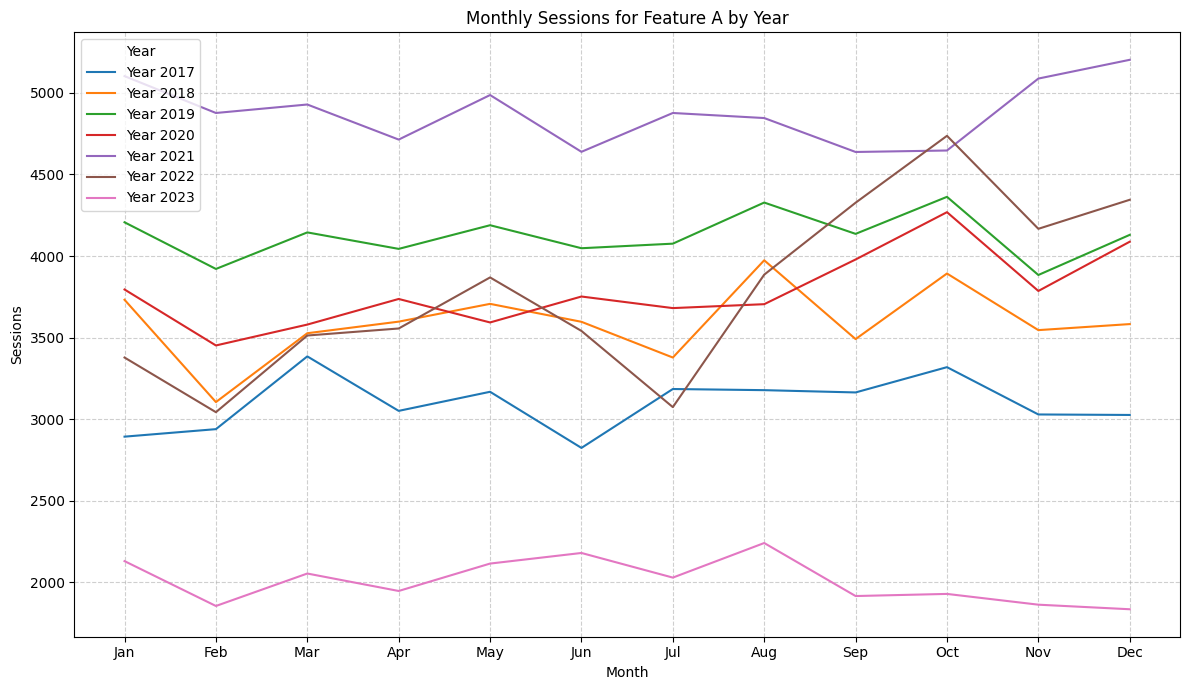

In [ ]:
feature_a_data = df_agg1[df_agg1.features == "A"]

plt.figure(figsize=(12, 7))

# Loop through each year and plot sessions vs month
for year in feature_a_data['year'].unique():
    yearly_data = feature_a_data[feature_a_data['year'] == year]
    plt.plot(yearly_data['month'], yearly_data['sessions'], label=f'Year {year}')

plt.title('Monthly Sessions for Feature A by Year')
plt.xlabel('Month')
plt.ylabel('Sessions')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Year')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

<BarContainer object of 7 artists>

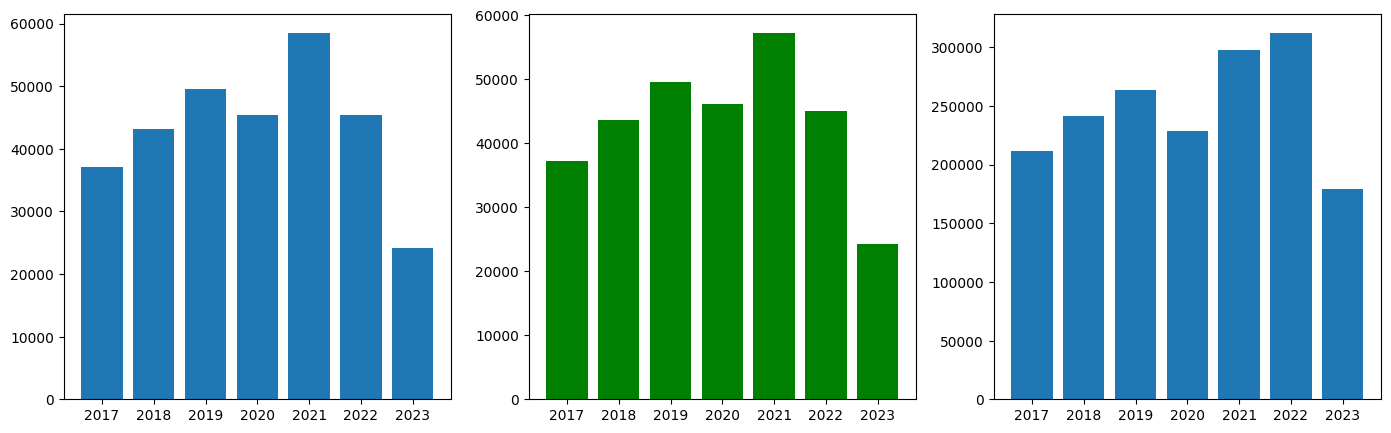

In [ ]:
fig,ax = plt.subplots(1,3,figsize = (17,5))
ax[0].bar(df_agg1[df_agg1.features=="A"]["year"],df_agg1[df_agg1.features=="A"]["sessions"])
ax[1].bar(df_agg1[df_agg1.features=="B"]["year"],df_agg1[df_agg1.features=="B"]["sessions"],color = "green")
ax[2].bar(df_agg1[df_agg1.features=="C"]["year"],df_agg1[df_agg1.features=="C"]["time_spent"])

In [ ]:
df_agg1.sort_values(["year","features"])

,year,features,sessions,time_spent
0,2017,A,37161,211181
1,2017,B,37227,212948
2,2017,C,36995,211589
3,2017,D,37113,211162
4,2017,E,36797,210386
5,2017,F,37579,212516
6,2017,G,36382,207717
7,2017,H,36914,209051
8,2018,A,43131,237765
9,2018,B,43563,240028


In [ ]:
df_agg1['sessions_yoy_pct_change'] = df_agg1.sort_values(["year","features"]).groupby("features")["sessions"].pct_change()
df_agg1[df_agg1.features =="A"]

,year,features,sessions,time_spent,sessions_yoy_pct_change
0,2017,A,37161,211181,NaN
8,2018,A,43131,237765,0.160652
16,2019,A,49471,262110,0.146994
24,2020,A,45417,230873,-0.081947
32,2021,A,58548,302179,0.289121
40,2022,A,45436,311417,-0.223953
48,2023,A,24094,182072,-0.469716


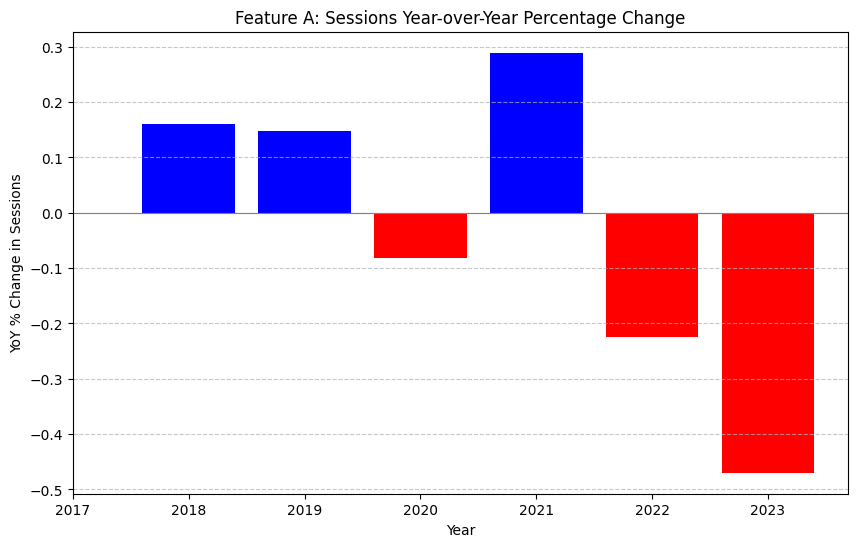

In [ ]:
feature_a_data = df_agg1[df_agg1.features == "A"]

# Create a list of colors: 'red' for negative, 'blue' for positive
colors = ['red' if x < 0 else 'blue' for x in feature_a_data["sessions_yoy_pct_change"]]

plt.figure(figsize=(10, 6))
plt.bar(feature_a_data["year"], feature_a_data["sessions_yoy_pct_change"], color=colors)
plt.title('Feature A: Sessions Year-over-Year Percentage Change')
plt.xlabel('Year')
plt.ylabel('YoY % Change in Sessions')
plt.axhline(0, color='grey', linewidth=0.8) # Add a horizontal line at 0 for reference
plt.xticks(feature_a_data["year"])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Level 12 - Functions and pipleines

In [ ]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'donor_id': ['D001','D002','D003','D004','D005','D006','D007','D008'],
    'name':     ['alice smith','BOB JONES','Carol White','DAVE BROWN',
                 'eve davis','Frank Miller','GRACE LEE','hank wilson'],
    'region':   ['North','South','North','East','South','West','North','East'],
    'donation': [1200, 45, 890, 320, 1500, 60, 430, 780],
    'score':    [88, 72, 91, 65, 95, 58, 84, 79],
    'joined':   ['2021-03-15','2020-07-20','2022-01-05','2022-11-30',
                 '2019-08-14','2022-03-01','2023-06-22','2021-05-10']
})
#1. Use apply with a named function to clean name — title case, stripped
def named_func(x:str):
  x = x.strip()
  x = x.title()
  return x

#Use apply with a lambda to create donation_category
df["name"] = df.name.apply(lambda x:named_func(x) )

def categorize (x:float):
  if x<500:
    y = 'Small'
  elif x<1000:
    y = "Mid"
  else:
    y = "Major"

  return y


df["don_cat"] = df.donation.apply(lambda x :categorize(x) )

df["donor_summary"] = df.apply(lambda row :f"{row["name"]} | {row["region"]} | ${row["donation"]:,.2f}",axis = 1)


def cleaned_df(df:pd.DataFrame):
  df["name"] = df.name.apply(lambda x:named_func(x) )
  df["don_cat"] = df.donation.apply(lambda x :categorize(x) )
  df.joined = pd.to_datetime(df.joined)
  return df

df = df.pipe(cleaned_df)
df["high_value"] = df.apply(lambda row : True if (row["donation"]>500) & (row["score"]>80) else False, axis = 1)
df.head()

,donor_id,name,region,donation,score,joined,don_cat,donor_summary,high_value
0,D001,Alice Smith,North,1200,88,2021-03-15,Major,"Alice Smith | North | $1,200.00",True
1,D002,Bob Jones,South,45,72,2020-07-20,Small,Bob Jones | South | $45.00,False
2,D003,Carol White,North,890,91,2022-01-05,Mid,Carol White | North | $890.00,True
3,D004,Dave Brown,East,320,65,2022-11-30,Small,Dave Brown | East | $320.00,False
4,D005,Eve Davis,South,1500,95,2019-08-14,Major,"Eve Davis | South | $1,500.00",True


In [ ]:
def clean_df(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.copy()
        .assign(
            name              = lambda d: d['name'].apply(named_func),
            donation_category = lambda d: d['donation'].apply(categorize),
            joined            = lambda d: pd.to_datetime(d['joined'])
        )
    )

In [ ]:
clean_df(df)

,donor_id,name,region,donation,score,joined,don_cat,donor_summary,high_value,donation_category
0,D001,Alice Smith,North,1200,88,2021-03-15,Major,"Alice Smith | North | $1,200.00",True,Major
1,D002,Bob Jones,South,45,72,2020-07-20,Small,Bob Jones | South | $45.00,False,Small
2,D003,Carol White,North,890,91,2022-01-05,Mid,Carol White | North | $890.00,True,Mid
3,D004,Dave Brown,East,320,65,2022-11-30,Small,Dave Brown | East | $320.00,False,Small
4,D005,Eve Davis,South,1500,95,2019-08-14,Major,"Eve Davis | South | $1,500.00",True,Major
5,D006,Frank Miller,West,60,58,2022-03-01,Small,Frank Miller | West | $60.00,False,Small
6,D007,Grace Lee,North,430,84,2023-06-22,Small,Grace Lee | North | $430.00,False,Small
7,D008,Hank Wilson,East,780,79,2021-05-10,Mid,Hank Wilson | East | $780.00,False,Mid


#statistcs - scipy

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# Our dataset — donor campaign data
donations = [1200, 45, 890, 320, 1500, 60, 430, 780, 95, 210]
scores    = [88, 72, 91, 65, 95, 58, 84, 79, 61, 73]

In [ ]:
results = stats.describe(donations)
print(results)

DescribeResult(nobs=np.int64(10), minmax=(np.int64(45), np.int64(1500)), mean=np.float64(553.0), variance=np.float64(264273.3333333334), skewness=np.float64(0.6622911455887313), kurtosis=np.float64(-0.9110372142114254))


In [ ]:
np.median(donations)
stats.mode(donations)

ModeResult(mode=np.int64(45), count=np.int64(1))

In [ ]:
stats.trim_mean(donations , proportiontocut = 0.1)

np.float64(498.125)

In [ ]:
#spread and variability
np.var(donations,ddof = 1)
np.std(donations,ddof = 1)

np.float64(264273.3333333333)

In [ ]:
donations = [1200, 45, 890, 320, 1500, 60, 430, 780, 95, 210]
donations.sort()
donations

[45, 60, 95, 210, 320, 430, 780, 890, 1200, 1500]

In [ ]:
stats.iqr(donations)

np.float64(738.75)

In [ ]:
Q1  = np.percentile(donations, 25)      # 25th percentile
Q3  = np.percentile(donations, 75)
print(Q1,Q3)
print(Q3-Q1)

123.75 862.5
738.75


In [ ]:
np.percentile(donations,10)

np.float64(58.5)

In [ ]:
z_scores = stats.zscore(donations,ddof = 1)
z_scores

array([-0.98818223, -0.95900362, -0.8909202 , -0.66721753, -0.45324106,
       -0.2392646 ,  0.44156962,  0.65554609,  1.25857068,  1.84214286])

In [ ]:
donations

[45, 60, 95, 210, 320, 430, 780, 890, 1200, 1500]

In [ ]:
x = stats.describe(donations).mean
y = np.std(donations,ddof = 1)
print(x,y)

553.0 514.0752214737969


In [ ]:
(donations - x )/y

array([-0.98818223, -0.95900362, -0.8909202 , -0.66721753, -0.45324106,
       -0.2392646 ,  0.44156962,  0.65554609,  1.25857068,  1.84214286])

In [ ]:
donations

[45, 60, 95, 210, 320, 430, 780, 890, 1200, 1500]

In [ ]:
(780-553.0 )/514.0752214737969

0.4415696196156198

In [ ]:
outliers = np.array(donations)[np.abs(z_scores) > 1]
outliers

array([1200, 1500])

In [ ]:
stats.pearsonr(donations, scores)

PearsonRResult(statistic=np.float64(-0.32125911098558957), pvalue=np.float64(0.3653941709873414))

In [ ]:
sp_corr, sp_p = stats.spearmanr(donations, scores)

In [ ]:
norm_dist = stats.norm(loc=553, scale=522)
norm_dist.pdf(553)
norm_dist.cdf(553)

np.float64(0.5)

In [ ]:
norm_dist.rvs(size=5)

array([ 257.7195609 ,  909.62361132, 1249.14439058,  688.40824903,
       -271.68775387])

In [ ]:
stats.normaltest(donations)

NormaltestResult(statistic=np.float64(1.5006960901447814), pvalue=np.float64(0.4722021764968011))

In [ ]:
# Two-sample t-test — are these two groups different?
vip_donations    = [1200, 1500, 780]
active_donations = [320, 60, 95, 210]

t_stat, p_value = stats.ttest_ind(vip_donations, active_donations)

# Interpreting:
# p < 0.05  → groups are significantly different ✅
# p >= 0.05 → difference could be random chance

print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.3f}")
print("Significant!" if p_value < 0.05 else "Not significant")

t-statistic: 5.255
p-value: 0.003
Significant!


In [ ]:
print(np.mean(vip_donations))
print(np.mean(active_donations))

1160.0
171.25


# Level 22 - Descriptive Statistics

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.DataFrame({
    'donor_id':  ['D001','D002','D003','D004','D005','D006','D007','D008','D009','D010'],
    'region':    ['North','South','North','East','South','West','North','East','South','West'],
    'status':    ['Active','VIP','Inactive','Active','VIP','Active','Inactive','VIP','Active','Inactive'],
    'donation':  [1200, 45, 890, 320, 1500, 60, 430, 780, 95, 210],
    'score':     [88, 72, 91, 65, 95, 58, 84, 79, 61, 73],
    'age':       [34, 28, 45, 52, 31, 47, 38, 29, 55, 41]
})

#Calculate mean, median, std, variance for donation and score — in one summary DataFrame

col_names = ['mean', 'median', 'std', 'variance']
index_value = ['donation','score']

def summary_stats(df):
  return np.mean(df),np.median(df),np.std(df),np.var(df)

summary_dataframe = pd.DataFrame(columns = col_names,index = index_value)
summary_dataframe.loc["donation",:] = summary_stats(df["donation"])
summary_dataframe.loc["score",:] = summary_stats(df["score"])
summary_dataframe

#Calculate the IQR for donation — show Q1, Q3, lower bound, upper bound
from scipy import stats
q1 = np.percentile(df.donation,25)
q3 = np.percentile(df.donation,75)
iqr = q3 -q1
print(iqr)
stats.iqr(df.donation)
lower_bound = q1-1.5*iqr
upper_bound = q3+1.5*iqr

#Use scipy.stats.describe on donation — print and explain each field in a comment
print(stats.describe(df.donation))
#Calculate skewness and kurtosis for donation — interpret in a comment
stats.describe(df.donation).skewness #right skew
stats.describe(df.donation).kurtosis #not fat tails#light tails
#Build a reusable stats_profile(series) function returning a clean summary Series:mean, median, std, variance, min, max, IQR, skewness, kurtosis
def stats_profile(df:pd.Series):
  return np.mean(df),np.median(df),np.std(df),np.var(df),np.min(df),np.max(df),stats.iqr(df),stats.skew(df),stats.kurtosis(df)
#Apply stats_profile to both donation and score — side by side in one DataFrame
stats_profile_df = pd.DataFrame(index = ['donation','score'],columns = ['mean', 'median', 'std', 'variance', 'min','max', 'IQR', 'skewness', 'kurtosis'])
stats_profile_df.loc["donation",:] = stats_profile(df.donation)
stats_profile_df.loc["score",:] = stats_profile(df.score)
stats_profile_df.loc["age",:] = stats_profile(df.age)
#Which region has the highest variance in donation amounts — one line
x = df.groupby("region").agg(var_region = ("donation","var")).reset_index()
x.sort_values('var_region',ascending = False).loc[0,:]

738.75
DescribeResult(nobs=np.int64(10), minmax=(np.int64(45), np.int64(1500)), mean=np.float64(553.0), variance=np.float64(264273.3333333334), skewness=np.float64(0.6622911455887313), kurtosis=np.float64(-0.9110372142114254))


#Outlier detection

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.DataFrame({
    'donor_id': ['D001','D002','D003','D004','D005','D006','D007','D008','D009','D010',
                 'D011','D012'],
    'region':   ['North','South','North','East','South','West','North','East','South',
                 'West','North','East'],
    'donation': [1200, 45, 890, 320, 15000, 60, 430, 780, 95, 210, 25000, 18],
    'score':    [88, 72, 91, 65, 95, 58, 84, 79, 61, 73, 99, 12],
    'age':      [34, 28, 45, 52, 31, 47, 38, 29, 55, 41, 36, 44]
})
df.donation = pd.to_numeric(df.donation).astype('float')

from scipy import stats
#outliers iqr method
def iqr_stats(df:pd.Series):
  q1 = np.percentile(df,25)
  q3 = np.percentile(df,75)
  iqr = stats.iqr(df)
  assert iqr == q3-q1 ,"iqr <> q3-q1 ;something is funky with iqr"
  lower_bound = q1 -1.5*iqr
  upper_bound = q3 +1.5*iqr
  print(lower_bound,upper_bound)
  return q1,q3,iqr,upper_bound,lower_bound

q1,q3,iqr,upper_bound,lower_bound = iqr_stats(df.donation)
df ["donation_outlier_iqr"] = (df.donation <lower_bound) | (df.donation >upper_bound)
df[df['donation_outlier_iqr']==True]

#outliers z-score method
print(np.mean(df.donation))
don_std = np.std(df.donation,ddof = 1)
print(don_std)
z_score = stats.zscore(df.donation,ddof = 1)
print(z_score)

df["outlier_zscore"] = (np.abs(z_score) > 3*don_std)
df["flagged_by_both"] = df["donation_outlier_iqr"]*df["outlier_zscore"]

q1,q3,iqr,upper_bound,lower_bound = iqr_stats(df.score)
df ["score_outlier_iqr"] = (df.score <lower_bound) | (df.score >upper_bound)
df[df['score_outlier_iqr']==True]

fig,ax = plt.subplots(1,2,figsize = (17,9))
ax[0].boxplot(df.donation)
ax[1].scatter(df.score,df.donation)
ax[1].scatter(df[df["donation_outlier_iqr"]==True].score,df[df["donation_outlier_iqr"]==True].donation,color ="red")
ax[1].scatter(df[df["score_outlier_iqr"]==True].score,df[df["score_outlier_iqr"]==True].donation,color ="red")
ax[1].set_ylabel("donation")
ax[1].set_xlabel("score")


def flag_outliers(df,col):
  df_copy = df.copy()
  q1,q3,iqr,upper_bound,lower_bound = iqr_stats(df_copy[f"{col}"])
  df_copy[f"{col}_outlier_flag"] = (df_copy[f"{col}"] <lower_bound) | (df_copy[f"{col}"] >upper_bound)

  return df_copy

def remove_outliers(df,col):
  df_copy = flag_outliers(df,col)
  df_copy = df_copy[df_copy[f"{col}_outlier_flag"]==False ]
  return df_copy
df

-1235.625 2289.375
3670.6666666666665
7928.666909997984
[-0.31161186 -0.45728578 -0.35071049 -0.42260152  1.42890772 -0.45539392
 -0.40872781 -0.3645842  -0.45097955 -0.43647522  2.69015379 -0.46069115]
26.875 125.875


,donor_id,region,donation,score,age,donation_outlier_iqr,outlier_zscore,flagged_by_both,score_outlier_iqr
0,D001,North,1200.0,88,34,False,False,False,False
1,D002,South,45.0,72,28,False,False,False,False
2,D003,North,890.0,91,45,False,False,False,False
3,D004,East,320.0,65,52,False,False,False,False
4,D005,South,15000.0,95,31,True,False,False,False
5,D006,West,60.0,58,47,False,False,False,False
6,D007,North,430.0,84,38,False,False,False,False
7,D008,East,780.0,79,29,False,False,False,False
8,D009,South,95.0,61,55,False,False,False,False
9,D010,West,210.0,73,41,False,False,False,False


#AB Testing

             mean median     std
donation   200.17  177.5  108.38
converted     0.7    1.0    0.46

don_a is normal
don_b is normal
con_a is not normal
con_b is not normal

2.2405431724081497 0.028900628447709437
Group A summary stats : (np.float64(230.5), np.float64(210.0), 118.77)
Group B summary stats : (np.float64(169.83), np.float64(155.0), 88.81)
Significant
2.2405431724081497 0.014450314223854718

one tailed test
Significant
-2.2405431724081497 0.014450314223854718
0.5785057595463666

 confidence intervals
(np.float64(186.14868708899758), np.float64(274.8513129110024))
(np.float64(136.67150405730422), np.float64(202.99516260936247))
0.43969686527576407


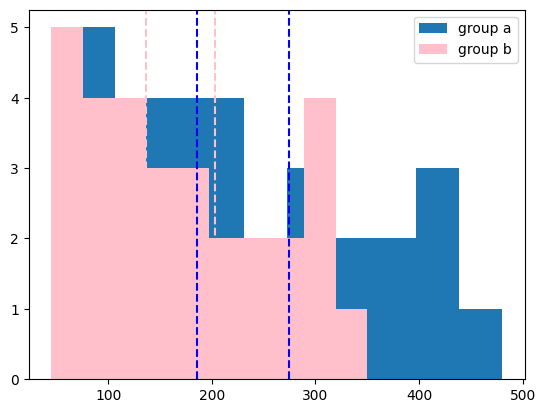

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

np.random.seed(42)

# Two campaign groups — A and B
campaign_a = pd.DataFrame({
    'donor_id':  [f'A{i:03d}' for i in range(1, 31)],
    'group':     ['A'] * 30,
    'donation':  [120, 85, 200, 340, 95, 180, 420, 75, 260, 310,
                  140, 90, 380, 155, 220, 480, 65, 295, 175, 410,
                  130, 245, 190, 320, 110, 360, 285, 150, 230, 400],
    'converted': [1,0,1,1,0,1,1,0,1,1, 1,0,1,1,1,1,0,1,1,1,
                  1,1,1,1,0,1,1,1,1,1]
})

campaign_b = pd.DataFrame({
    'donor_id':  [f'B{i:03d}' for i in range(1, 31)],
    'group':     ['B'] * 30,
    'donation':  [95, 60, 150, 280, 70, 130, 310, 55, 190, 240,
                  100, 65, 290, 115, 160, 350, 45, 215, 125, 300,
                  90, 175, 140, 230, 80, 260, 205, 110, 170, 290],
    'converted': [0,0,1,1,0,1,1,0,1,1, 0,0,1,0,1,1,0,1,0,1,
                  0,1,1,1,0,1,1,0,1,1]
})

df = pd.concat([campaign_a, campaign_b], ignore_index=True)

def summary_stats(df,col,ddof = 1):
  df_mean = round(np.mean(df[f"{col}"]),2)
  df_median = round(np.median(df[f"{col}"]),2)
  df_std = round(np.std(df[f"{col}"],ddof = 1),2)
  return df_mean,df_median,df_std

def ht_results(p_val):
  if p_val < 0.05:
    print("Significant")
  else:
    print("not significant")

df_summary = pd.DataFrame(columns = ["mean","median","std"],index = ["donation","converted"])
df_summary.loc["donation",:] = summary_stats(df,"donation",ddof = 1)
df_summary.loc["converted",:] = summary_stats(df,"converted",ddof = 1)
print(df_summary)

df[df["group"]=="A"].loc[:,"donation"].isnull().sum() #checking for nulls in group A donated
df[df["group"]=="B"].loc[:,"donation"].isnull().sum() #checking for nulls in group B donated
df[df["group"]=="A"].loc[:,"converted"].isnull().sum() #checking for nulls in group A converted
df[df["group"]=="B"].loc[:,"converted"].isnull().sum() #checking for nulls in group B converted

don_a = list(df.loc[df["group"]=="A","donation"])
don_b = list(df.loc[df["group"]=="B","donation"])

con_a = list(df.loc[df["group"]=="A","converted"])
con_b = list(df.loc[df["group"]=="B","converted"])

df.group.value_counts() #looking at the sample size
print()

#checking normality assumptions
print("don_a is normal") if stats.normaltest(don_a)[1]>0.05 else print("don_a is not normal")
print("don_b is normal") if stats.normaltest(don_b)[1]>0.05 else print("don_b is not normal")

print("con_a is normal") if stats.normaltest(con_a)[1]>0.05 else print("con_a is not normal")
print("con_b is normal") if stats.normaltest(con_b)[1]>0.05 else print("con_b is not normal")
print()

#two-tailed test
from scipy import stats
t_stat, p_val = stats.ttest_ind(don_a,don_b,equal_var=True) ## since p-value <0.05, effect is significant and we reject null hypothesis
#stats.ttest_ind(don_a,don_b,equal_var=True).df
print(t_stat,p_val)
print("Group A summary stats :",summary_stats(df[df["group"]=="A"],"donation",ddof = 1))
print("Group B summary stats :",summary_stats(df[df["group"]=="B"],"donation",ddof = 1))
ht_results(p_val)

#one - tailed test
t_stat, p_val = stats.ttest_ind(don_a,don_b,equal_var=True,alternative = 'greater') ## mean(don_a) > mean(don_b)
#stats.ttest_ind(don_a,don_b,equal_var=True).df
print(t_stat,p_val) #note pval is half of 2 tailed test
print("\none tailed test")
ht_results(p_val)

#additional permutations
t_stat, p_val = stats.ttest_ind(don_b,don_a,equal_var=True,alternative = 'greater') ##  mean(don_b) > mean(don_a)
t_stat, p_val = stats.ttest_ind(don_b,don_a,equal_var=True,alternative = 'less') ##  mean(don_b) < mean(don_a) #same as above
#stats.ttest_ind(don_a,don_b,equal_var=True).df
print(t_stat,p_val) #note pval is half of 2 tailed test

## effect size measures how large or meaningful a difference of relationship is.
## large sample sizes may have very small p-values but their effect size should be taken into account.
## different effect size measures t-test <-> cohen's d; ANOVA <-> Eta squared
s_pooled = np.sqrt((np.std(don_a,ddof = 1)**2 + np.std(don_b,ddof = 1)**2)*29/58)
cohens_d = (np.mean(don_a) - np.mean(don_b))/s_pooled
print(cohens_d) #moderate effect

print("\n confidence intervals")
print(stats.t.interval(0.95,df = 29, loc = np.mean(don_a) ,scale = np.std(don_a,ddof = 1)/np.sqrt(len(don_a))))
print(stats.t.interval(0.95,df = 29, loc = np.mean(don_b) ,scale = np.std(don_b,ddof = 1)/np.sqrt(len(don_b))))

import matplotlib.pyplot as plt
plt.hist(don_a,label = "group a")
plt.hist(don_b,color = 'pink',label = "group b")
plt.axvline(stats.t.interval(0.95,df = 29, loc = np.mean(don_a) ,scale = np.std(don_a,ddof = 1)/np.sqrt(len(don_a)))[0],linestyle="--",color = "blue")
plt.axvline(stats.t.interval(0.95,df = 29, loc = np.mean(don_a) ,scale = np.std(don_a,ddof = 1)/np.sqrt(len(don_a)))[1],linestyle="--",color = "blue")
plt.axvline(stats.t.interval(0.95,df = 29, loc = np.mean(don_b) ,scale = np.std(don_b,ddof = 1)/np.sqrt(len(don_b)))[0],linestyle="--",color = "pink")
plt.axvline(stats.t.interval(0.95,df = 29, loc = np.mean(don_b) ,scale = np.std(don_b,ddof = 1)/np.sqrt(len(don_b)))[1],linestyle="--",color = "pink")
plt.legend()

stats.ttest_ind(con_a,con_b,alternative = "greater")
stats.ttest_ind(con_a,con_b) #conversion rate for a is higher, but not significantly

s_pooled = np.sqrt((np.std(con_a,ddof = 1)**2 + np.std(con_b,ddof = 1)**2)*29/58)
cohens_d = (np.mean(con_a) - np.mean(con_b))/s_pooled
print(cohens_d) #small effect

def ab_test_report(group_a,group_b,metric,alpha = 0.05):
  #run the tests
  na = len(group_a)
  nb = len(group_b)
  t_stat,p_val = stats.ttest_ind(group_a[f"{metric}"],group_b[f"{metric}"])

  if p_val < alpha:
    print("Significant")
  else:
    print("not significant")

  s_pooled = np.sqrt(((na-1)*(np.std(con_a,ddof = 1)**2) + (nb-1)*(np.std(con_b,ddof = 1)**2))/(na+nb-2))
  cohens_d = (np.mean(con_a) - np.mean(con_b))/s_pooled
   #small effect

  ci_a = stats.t.interval(0.95,df = na-1 ,loc = np.mean(group_a[f"{metric}"]),scale = np.std(group_a[f"{metric}"],ddof = 1)/np.sqrt(len(group_a)))
  ci_b = stats.t.interval(0.95,df = na-1 ,loc = np.mean(group_b[f"{metric}"]),scale = np.std(group_b[f"{metric}"],ddof = 1)/np.sqrt(len(group_b)))

  return {"p_val":p_val,"ci_a":ci_a,"ci_b":ci_b,"cohen's d":cohens_d}


#Level 25 - distributions and confidence intervals

probability of a value to be above 300: 27.92%
Value at 90th percentile :, 382.7162838257656
probability that exactly 8 go viral : 11.44
probability that atleast 5 go viral : 41.64
expected number of viral campaings : 6.0


(np.float64(-12.422145363261308), np.float64(473.4221453632613))

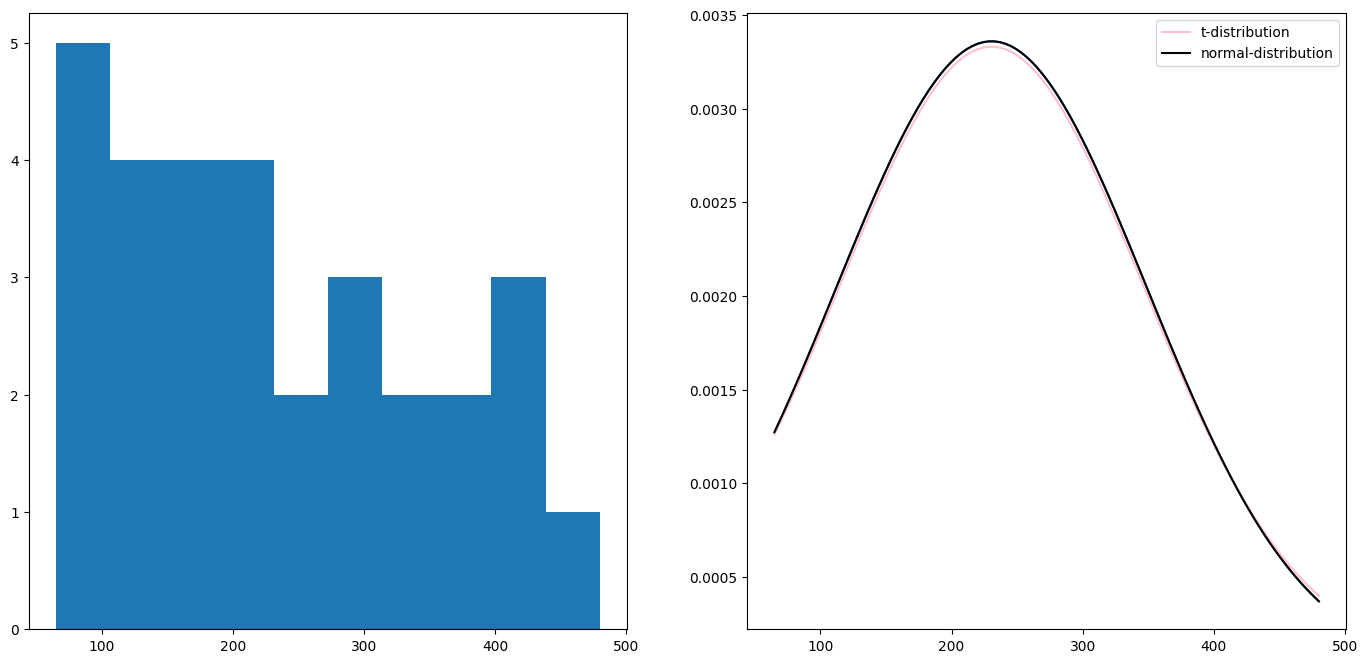

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# GoFundMe campaign dataset
np.random.seed(42)
donations = [120, 85, 200, 340, 95, 180, 420, 75, 260, 310,
             140, 90, 380, 155, 220, 480, 65, 295, 175, 410,
             130, 245, 190, 320, 110, 360, 285, 150, 230, 400]

n         = len(donations)        # 30
mean      = np.mean(donations)
std       = np.std(donations, ddof=1)
se        = std / np.sqrt(n)      # standard error

don_min, don_max = np.min(donations), np.max(donations)

fig ,ax = plt.subplots(1,2,figsize = (17,8))
#tests for normality
stats.shapiro(donations) #since p value >0.05, implies normal distribution
stats.normaltest(donations) #since p value >0.05, implies normal distribution
stats.describe(donations)#right skew, lighter tails
ax[0].hist(donations)

#Normal distribution — model donations as normal
don_n = stats.norm(loc = mean, scale = std)
x = np.linspace (don_min, don_max,1000)
y = don_n.pdf(x)
plt.plot(x,y)
print("probability of a value to be above 300:",f"{(1-don_n.cdf(300))*100:,.2f}%")
print("Value at 90th percentile :,",don_n.ppf(0.90))

#confidence intervals
conf_intervals_df = pd.DataFrame()
conf_intervals_df.loc["90%","ci lower"] = stats.t.interval(0.9,loc = mean,scale = se,df = n-1)[0]
conf_intervals_df.loc["90%","ci upper"] = stats.t.interval(0.9,loc = mean,scale = se,df = n-1)[1]

conf_intervals_df.loc["95%","ci lower"] = stats.t.interval(0.95,loc = mean,scale = se, df = n-1)[0]
conf_intervals_df.loc["95%","ci upper"] = stats.t.interval(0.95,loc = mean,scale = se, df = n-1)[1]

conf_intervals_df.loc["99%","ci lower"] = stats.t.interval(0.99,loc = mean, scale = se,df = n-1)[0]
conf_intervals_df.loc["99%","ci upper"] = stats.t.interval(0.99,loc = mean, scale = se,df = n-1)[1]

conf_intervals_df

#Binomial distribution — 30% of campaigns go viral:
#Out of 20 campaigns, what's the probability exactly 8 go viral?
#What's the probability at least 5 go viral?
#What's the expected number of viral campaigns?
b_dist = stats.binom(20,p=0.3)
print("probability that exactly 8 go viral :",f"{b_dist.pmf(8)*100:.2f}")
print("probability that atleast 5 go viral :",f"{b_dist.cdf(5)*100:.2f}")
print("expected number of viral campaings :",20*0.3)

#t-distribution vs normal — explain in code + comments:
#When do you use stats.norm vs stats.t?
#Show the difference in CI width for n=5 vs n=100

t_dist = stats.t(loc = mean, scale = std,df = n-1)
n_dist = stats.norm(loc = mean, scale = std)
x = np.linspace(don_min,don_max,100)
y_t = t_dist.pdf(x)
y_n = n_dist.pdf(x)

#we use t-distribution when assumptions abut normal dist cannopt be made for instance when sample size is small
ax[1].plot(x,y_t,color = "pink",label ="t-distribution")
ax[1].plot(x,y_n,color = "black",label ="normal-distribution")
ax[1].legend()

n=5
x = np.linspace(don_min,don_max,n)
y_t = t_dist.pdf(x)
mean      = np.mean(y_t)
std       = np.std(y_t, ddof=1)
se        = std / np.sqrt(n)      # standard error

# Corrected call to interval for a frozen distribution
t_dist.interval(0.95)

n=100
x = np.linspace(don_min,don_max,n)
y_t = t_dist.pdf(x)
mean      = np.mean(y_t)
std       = np.std(y_t, ddof=1)
se        = std / np.sqrt(n)      # standard error

# Corrected call to interval for a frozen distribution
t_dist.interval(0.95)

#bootstrapping
bootstrap_mean = []
n = len(donations)

for i in range(10000):
  sample = np.random.choice(donations,n)
  bootstrap_mean.append(np.mean(sample))

np.percentile(bootstrap_mean,[2.5,97.5])

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# GoFundMe campaign dataset
np.random.seed(42)
donations = [120, 85, 200, 340, 95, 180, 420, 75, 260, 310,
             140, 90, 380, 155, 220, 480, 65, 295, 175, 410,
             130, 245, 190, 320, 110, 360, 285, 150, 230, 400]

n         = len(donations)        # 30
mean      = np.mean(donations)
std       = np.std(donations, ddof=1)
se        = std / np.sqrt(n)      # standard error

for n in [5, 10, 30, 100]:
    se_n   = std / np.sqrt(n)
    ci     = stats.t.interval(0.95, df=n-1, loc=mean, scale=se_n)
    width  = ci[1] - ci[0]
    print(f"n={n:4d} → CI: [{ci[0]:.1f}, {ci[1]:.1f}] width={width:.1f}")

n=   5 → CI: [83.0, 378.0] width=295.0
n=  10 → CI: [145.5, 315.5] width=169.9
n=  30 → CI: [186.1, 274.9] width=88.7
n= 100 → CI: [206.9, 254.1] width=47.1


#Scikit Learn Preprocessing

12
3
12
['region_North' 'region_South' 'region_West' 'status_Inactive'
 'status_VIP']
12
12


UsageError: Line magic function `%inline` not found.


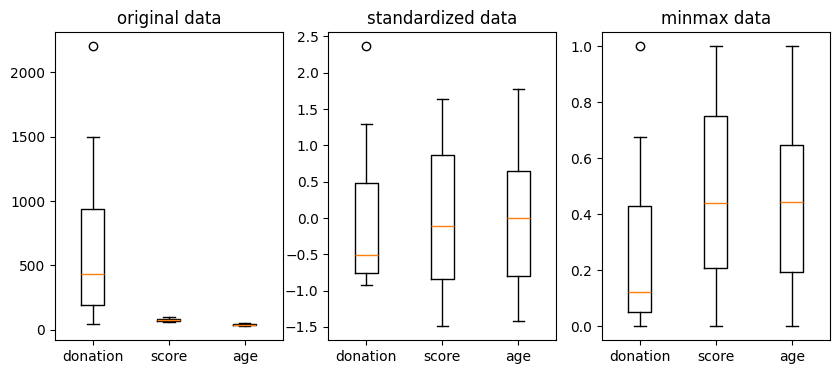

In [173]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

df = pd.DataFrame({
    'donor_id':    ['D001','D002','D003','D004','D005','D006','D007','D008',
                    'D009','D010','D011','D012','D013','D014','D015'],
    'region':      ['North','South','North','East','South','West','North','East',
                    'South','West','North','East','South','West','North'],
    'status':      ['Active','VIP','Inactive','Active','VIP','Active','Inactive',
                    'VIP','Active','Inactive','VIP','Active','VIP','Inactive','Active'],
    'donation':    [1200,45,890,320,1500,60,430,780,95,210,2200,980,175,430,300],
    'score':       [88,72,91,65,95,58,84,79,61,73,99,84,67,78,82],
    'age':         [34,28,45,52,31,47,38,29,55,41,36,44,39,51,43],
    'churned':     [0,1,0,0,1,1,0,0,1,1,0,0,1,1,0]
})

from sklearn.model_selection import train_test_split
train,test = train_test_split(df,train_size = 0.8,random_state = 42,stratify = df.churned)
print(len(train))
print(len(test))

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerical_cols = ['donation', 'score', 'age']
scaler.fit(train[numerical_cols]) # we fit only on train so that test data does not influence training
train_scaled = scaler.transform(train[numerical_cols])
test_scaled = scaler.transform(test[numerical_cols])
np.mean(train_scaled,axis = 0)
np.std(train_scaled,axis = 0)

minmax = MinMaxScaler()
minmax.fit(train[numerical_cols])
train_minmax = minmax.transform(train[numerical_cols])
test_minmax = minmax.transform(test[numerical_cols])
np.min(train_minmax,axis  = 0)
np.max(train_minmax,axis  = 0)

fig,ax = plt.subplots(1,3,figsize = (10,4))
ax[0].boxplot(df[["donation","score","age"]])
ax[0].set_title("original data")
ax[0].set_xticks(ticks = [1,2,3],labels = numerical_cols)
ax[1].boxplot(train_scaled)
ax[1].set_title("standardized data")
ax[1].set_xticks(ticks = [1,2,3],labels = numerical_cols)
ax[2].boxplot(train_minmax)
ax[2].set_title("minmax data")
ax[2].set_xticks(ticks = [1,2,3],labels = numerical_cols)

en = LabelEncoder()
en.fit_transform(train["status"]) #not recommended for nominal categories because numbers may be wrongly indicate order when there is none

en = OneHotEncoder(drop = "first")
# Fit the encoder on both 'region' and 'status'
x_onehot = en.fit_transform(train[["region","status"]])
print(len(train))
# To get all feature names generated by the encoder, call without arguments:
print(en.get_feature_names_out())
print(len(x_onehot.toarray()))
z = pd.concat([pd.DataFrame(x_onehot.toarray(),columns = en.get_feature_names_out()),train.reset_index(drop = True)],axis = 1)
print(len(z))


en = ColumnTransformer(transformers = [('num',StandardScaler(),['donation', 'score', 'age']),
                       ('cat',OneHotEncoder(drop  = "first"),["region","status"])])

X_transformed = en.fit_transform(train)
print(X_transformed)

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ("preprocessor", en),   # ColumnTransformer from above
    ("classifier", RandomForestClassifier())
])

# Suppose y = target labels
pipeline.fit(train.iloc[:,0:-1], train[["churned"]])
predictions = pipeline.predict(test)

#Classification

In [298]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [293]:
df = pd.DataFrame({
    'donor_id':    ['D001','D002','D003','D004','D005','D006','D007','D008',
                    'D009','D010','D011','D012','D013','D014','D015'],
    'region':      ['North','South','North','East','South','West','North','East',
                    'South','West','North','East','South','West','North'],
    'status':      ['Active','VIP','Inactive','Active','VIP','Active','Inactive',
                    'VIP','Active','Inactive','VIP','Active','VIP','Inactive','Active'],
    'donation':    [1200,45,890,320,1500,60,430,780,95,210,2200,980,175,430,300],
    'score':       [88,72,91,65,95,58,84,79,61,73,99,84,67,78,82],
    'age':         [34,28,45,52,31,47,38,29,55,41,36,44,39,51,43],
    'churned':     [0,1,0,0,1,1,0,0,1,1,0,0,1,1,0]
})

df = df.drop(columns = ["donor_id"])
x = df.iloc[:,0:-1]
y = df.iloc[:,-1]

x_train,x_test,y_train,y_test = train_test_split(x,y,train_size = 0.8,random_state = 42)
x_train = x_train.reset_index(drop = True)
x_test = x_test.reset_index(drop = True)
y_train = y_train.reset_index(drop = True)
y_test = y_test.reset_index(drop = True)

numeric_cols = ["donation","score","age"]
cat_cols = ["region","status"]

en = ColumnTransformer(\
                       transformers = [('num',StandardScaler(),numeric_cols),\
                        ('cat',OneHotEncoder(drop ='first'),cat_cols)])

x_train_scaled = pd.DataFrame(en.fit_transform(x_train),columns = en.get_feature_names_out())
x_test_scaled = pd.DataFrame(en.transform(x_test),columns = en.get_feature_names_out())

#Logistic regression
pipeline  = Pipeline([("preprocessor",en),("classifier",LogisticRegression())])
pipeline.fit(x_train,y_train)
pred_l = pipeline.predict(x_test)
pipeline.predict_proba(x_test)

#DecisionTree
pipeline  = Pipeline([("preprocessor",en),("classifier",DecisionTreeClassifier(max_depth = 3))])
pipeline.fit(x_train,y_train)
pred_tree = pipeline.predict(x_test)
pred_tree

feature_importance = pipeline.named_steps["classifier"].feature_importances_
feature_importance_dt = pd.DataFrame(feature_importance,index = list(pipeline.named_steps["preprocessor"].get_feature_names_out()),columns = ["feature importance"] )


pipeline = Pipeline([('preprocessor',en),('classifier',RandomForestClassifier())])
pipeline.fit(x_train,y_train)
pred_rf = pipeline.predict(x_test)
feature_importance = pipeline.named_steps["classifier"].feature_importances_
feature_importance_rf = pd.DataFrame(feature_importance,index = list(pipeline.named_steps["preprocessor"].get_feature_names_out()),columns = ["feature_imp_rf"])
feature_imp_pd = pd.concat([feature_importance_rf,feature_importance_dt],axis = 1)

pipeline = Pipeline([('preprocessor',en),('classifier',XGBClassifier())])
pipeline.fit(x_train,y_train)
pred_xgb = pipeline.predict(x_test)
feature_importance = pipeline.named_steps["classifier"].feature_importances_
feature_importance_xgb = pd.DataFrame(feature_importance,index = list(pipeline.named_steps["preprocessor"].get_feature_names_out()),columns = ["feature_imp_xgb"])
feature_imp_pd = pd.concat([feature_importance_rf,feature_importance_dt,feature_importance_xgb],axis = 1)

def accuracy(y_test,pred):
  return sum(y_test==pred)/len(y_test)

accuracy(y_test,pred_l)

acc = []
for i in range(10):
  pipeline  = Pipeline([("preprocessor",en),("classifier",DecisionTreeClassifier(max_depth = i+1))])
  pipeline.fit(x_train,y_train)
  pred_tree = pipeline.predict(x_test)
  acc.append(accuracy(y_test,pred_tree))
  #overfitting begins at 2
#pred vs predict_proba : predict has a cutoff threshold on 0.5, when we want to change this threshold we must use predict_proba

,region,status,donation,score,age,churned
0,North,Active,1200,88,34,0
1,South,VIP,45,72,28,1
2,North,Inactive,890,91,45,0
3,East,Active,320,65,52,0
4,South,VIP,1500,95,31,1
5,West,Active,60,58,47,1
6,North,Inactive,430,84,38,0
7,East,VIP,780,79,29,0
8,South,Active,95,61,55,1
9,West,Inactive,210,73,41,1


#Model Evaluation

In [345]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score,
                             classification_report, RocCurveDisplay)
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'donor_id':    ['D001','D002','D003','D004','D005','D006','D007','D008',
                    'D009','D010','D011','D012','D013','D014','D015'],
    'region':      ['North','South','North','East','South','West','North','East',
                    'South','West','North','East','South','West','North'],
    'status':      ['Active','VIP','Inactive','Active','VIP','Active','Inactive',
                    'VIP','Active','Inactive','VIP','Active','VIP','Inactive','Active'],
    'donation':    [1200,45,890,320,1500,60,430,780,95,210,2200,980,175,430,300],
    'score':       [88,72,91,65,95,58,84,79,61,73,99,84,67,78,82],
    'age':         [34,28,45,52,31,47,38,29,55,41,36,44,39,51,43],
    'churned':     [0,1,0,0,1,1,0,0,1,1,0,0,1,1,0]
})
df.drop(columns = ['donor_id'],inplace = True)
x = df.iloc[:,0:-1]
y = df.iloc[:,-1]

x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,stratify = df["churned"])
assert (len(x_train)==len(y_train)) & (len(x_test)==len(y_test)),"x,y train test sizes mismatch"

en = ColumnTransformer(transformers = [('cat',OneHotEncoder(drop = "first"),["region","status"]),
                                       ('num',StandardScaler(),["donation","score","age"])])


pipeline = Pipeline([("preprocess",en),("classify",RandomForestClassifier())])
print(pipeline.fit(x_train,y_train))
y_pred = pipeline.predict(x_test)
y_pred


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['region', 'status']),
                                                 ('num', StandardScaler(),
                                                  ['donation', 'score',
                                                   'age'])])),
                ('classify', RandomForestClassifier())])


array([0, 0, 0])

In [344]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['region', 'status']),
                                                 ('num', StandardScaler(),
                                                  ['donation', 'score',
                                                   'age'])])),
                ('classify', RandomForestClassifier())])

In [348]:
confusion_matrix(y_test,y_pred)

array([[2, 0],
       [1, 0]])